# Notebook - Find best Drug compound for `Ebola virus (Ebola + Zaire Ebola)`

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [114]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [115]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

#Needed to show molecules
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
from rdkit.Chem import PandasTools
import seaborn as sns
from copy import deepcopy
import pickle
from PIL import Image

import sys
sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [116]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [117]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
saveDir = os.path.join(resultsDir, "combinedEbolaVirus_bestMACAW/")
DORANETmoleculesDataDir = os.path.join(dataDir, 'DORAnet_molecules/')
ARTresultsDir = os.path.join(dataDir, 'Results/combinedEbolaVirus_bestMACAW/')
os.makedirs(saveDir, exist_ok=True)

Read data for Ebola virus

In [118]:
allVirusData_chEMBL_wMACAW = pd.read_csv(modelBuildingDataDir + 'allVirusData_chEMBL_uM_wMACAW.csv')
EbolavirusData_chEMBL_uM = allVirusData_chEMBL_wMACAW[allVirusData_chEMBL_wMACAW['Virus'] == 'Ebola']
EbolavirusData_chEMBL_uM = EbolavirusData_chEMBL_uM.rename(columns={'Virus': 'strain'})
EbolavirusData_chEMBL_uM

,Unnamed: 0,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,macaw_5,macaw_6,macaw_7,macaw_8,macaw_9,macaw_10,macaw_11,macaw_12,macaw_13,macaw_14
13073,41083,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...,265.2700,Small molecule,100000.0000,nM,...,0.0061,0.0323,-0.0055,0.0149,-0.0683,0.0023,0.0283,-0.0376,-0.0150,0.0675
13074,41086,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,C12H14N4O3,PCJCKCSFBICBNZ-NRZXQICZSA-N,InChI=1S/C12H14N4O3/c13-12-9-7(1-2-14-12)16(5-...,262.2700,Small molecule,320.0000,nM,...,0.0199,0.0233,0.0013,0.0287,-0.0153,0.0335,0.0075,-0.0099,0.0034,0.0092
13075,41087,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C37H42N3O5P,BCNOLUKYPQLFDY-UHFFFAOYSA-N,"InChI=1S/C37H42N3O5P/c1-3-43-46(41,44-4-2)27-3...",639.7300,Unknown,1880.0000,nM,...,0.0111,0.0181,0.0116,-0.0074,-0.0229,-0.0406,-0.0337,-0.0069,0.0205,0.0031
13076,41088,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C38H41F3N3O5P,YPONQFDDBHJAOJ-UHFFFAOYSA-N,"InChI=1S/C38H41F3N3O5P/c1-3-47-50(45,48-4-2)26...",707.7300,Unknown,2490.0000,nM,...,0.0180,0.0163,0.0107,0.0020,-0.0264,-0.0366,-0.0280,-0.0035,0.0120,0.0031
13077,41089,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,C43H65N6O9P,VXYCOVDOXKSLFC-NKSQPNMBSA-N,InChI=1S/C43H65N6O9P/c1-5-8-9-10-11-12-13-14-1...,841.0000,Unknown,50000.0000,nM,...,-0.0154,0.0184,0.0676,-0.0673,0.0141,0.0085,0.0191,-0.0017,-0.0874,-0.0151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13794,42032,CHEMBL5591747,CCN1CCN(CCCC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)...,C20H36N2O2,NUMKCFVODGNSTL-XKGZKEIXSA-N,InChI=1S/C20H36N2O2/c1-5-21-11-13-22(14-12-21)...,336.5200,NaN,5300.0000,nM,...,-0.0170,-0.0035,0.0126,0.0313,-0.0368,-0.0033,0.0178,0.0141,0.0320,-0.0122
13795,42033,CHEMBL5592622,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCN(C)CC...,C17H30N2O2,BGOGHLRTERBUFT-LXTVHRRPSA-N,"InChI=1S/C17H30N2O2/c1-12-14-9-13(17(14,2)3)10...",294.4400,NaN,34000.0000,nM,...,-0.0157,-0.0269,0.0155,0.0423,-0.0285,0.0094,0.0252,0.0456,0.0115,-0.0402
13796,42034,CHEMBL221722,NC(=O)c1nc(F)cnc1O,C5H4FN3O2,ZCGNOVWYSGBHAU-UHFFFAOYSA-N,InChI=1S/C5H4FN3O2/c6-2-1-8-5(11)3(9-2)4(7)10/...,157.1000,Small molecule,61880.0000,nM,...,0.0221,0.0555,0.0268,-0.0877,-0.0518,0.0783,0.3203,0.0077,0.0029,0.2260
13797,42035,CHEMBL5595942,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCN1CCOCC1,C17H29NO3,MBWOXPVSSAKRDX-JLJPHGGASA-N,"InChI=1S/C17H29NO3/c1-16(2)13-4-6-17(3,12-13)1...",295.4200,NaN,34000.0000,nM,...,-0.0167,0.0083,0.0198,0.0370,-0.0540,-0.0150,0.0074,0.0015,0.0342,-0.0066


Read data for Zaire Ebola

In [119]:
EbolavirusAllStrainData_chEMBL_uM = pd.read_csv(modelBuildingDataDir + 'EbolaAllStrainsData_chEMBL_uM.csv')
EbolavirusAllStrainData_chEMBL_uM

,Unnamed: 0,strain,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,...,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,value_uM,pPotency,pPotencyMid
0,2,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...,265.2700,Small molecule,100000.0000,...,0.7000,19.0000,2.0000,0.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,100.0000,NaN,4.0000
1,5,Ebola,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,C12H14N4O3,PCJCKCSFBICBNZ-NRZXQICZSA-N,InChI=1S/C12H14N4O3/c13-12-9-7(1-2-14-12)16(5-...,262.2700,Small molecule,320.0000,...,0.5600,19.0000,2.0000,0.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,0.3200,NaN,6.4949
2,6,Ebola,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C37H42N3O5P,BCNOLUKYPQLFDY-UHFFFAOYSA-N,"InChI=1S/C37H42N3O5P/c1-3-43-46(41,44-4-2)27-3...",639.7300,Unknown,1880.0000,...,0.1200,46.0000,5.0000,2.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,1.8800,5.7258,5.7258
3,7,Ebola,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C38H41F3N3O5P,YPONQFDDBHJAOJ-UHFFFAOYSA-N,"InChI=1S/C38H41F3N3O5P/c1-3-47-50(45,48-4-2)26...",707.7300,Unknown,2490.0000,...,0.1200,50.0000,5.0000,2.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,2.4900,5.6038,5.6038
4,8,Ebola,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,C43H65N6O9P,VXYCOVDOXKSLFC-NKSQPNMBSA-N,InChI=1S/C43H65N6O9P/c1-5-8-9-10-11-12-13-14-1...,841.0000,Unknown,50000.0000,...,0.0400,59.0000,3.0000,3.0000,CHEMBL4434621,Ebolavirus,Ebolavirus,50.0000,NaN,4.3010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,1420,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.6200,NaN,520.0000,...,0.3400,34.0000,4.0000,1.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.5200,6.2840,6.2840
1108,1421,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.6200,NaN,520.0000,...,0.3400,34.0000,4.0000,1.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.5200,6.2840,6.2840
1109,1422,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.6100,NaN,1900.0000,...,0.3500,33.0000,3.0000,0.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.9000,5.7212,5.7212
1110,1423,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.6100,NaN,1900.0000,...,0.3500,33.0000,3.0000,0.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.9000,5.7212,5.7212


In [120]:
ZaireEbolavirusData_chEMBL_uM = EbolavirusAllStrainData_chEMBL_uM[EbolavirusAllStrainData_chEMBL_uM['strain'] == 'ZaireEbola']
ZaireEbolavirusData_chEMBL_uM

,Unnamed: 0,strain,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,...,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,value_uM,pPotency,pPotencyMid
977,1262,ZaireEbola,CHEMBL221722,NC(=O)c1nc(F)cnc1O,C5H4FN3O2,ZCGNOVWYSGBHAU-UHFFFAOYSA-N,InChI=1S/C5H4FN3O2/c6-2-1-8-5(11)3(9-2)4(7)10/...,157.1000,Small molecule,67000.0000,...,0.5700,11.0000,1.0000,0.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,67.0000,4.1739,4.1739
978,1263,ZaireEbola,CHEMBL221722,NC(=O)c1nc(F)cnc1O,C5H4FN3O2,ZCGNOVWYSGBHAU-UHFFFAOYSA-N,InChI=1S/C5H4FN3O2/c6-2-1-8-5(11)3(9-2)4(7)10/...,157.1000,Small molecule,67000.0000,...,0.5700,11.0000,1.0000,0.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,67.0000,4.1739,4.1739
979,1264,ZaireEbola,CHEMBL221722,NC(=O)c1nc(F)cnc1O,C5H4FN3O2,ZCGNOVWYSGBHAU-UHFFFAOYSA-N,InChI=1S/C5H4FN3O2/c6-2-1-8-5(11)3(9-2)4(7)10/...,157.1000,Small molecule,24000.0000,...,0.5700,11.0000,1.0000,0.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,24.0000,4.6198,4.6198
980,1265,ZaireEbola,CHEMBL221722,NC(=O)c1nc(F)cnc1O,C5H4FN3O2,ZCGNOVWYSGBHAU-UHFFFAOYSA-N,InChI=1S/C5H4FN3O2/c6-2-1-8-5(11)3(9-2)4(7)10/...,157.1000,Small molecule,24000.0000,...,0.5700,11.0000,1.0000,0.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,24.0000,4.6198,4.6198
981,1266,ZaireEbola,CHEMBL5611967,O=C(Nc1cccc(Cl)c1)c1ccc(-c2cccc(OC3CCNCC3)c2)s1,C22H21ClN2O2S,ADGQEJABTJNTPK-UHFFFAOYSA-N,InChI=1S/C22H21ClN2O2S/c23-16-4-2-5-17(14-16)2...,412.9400,NaN,1860.0000,...,0.5900,28.0000,3.0000,1.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.8600,5.7305,5.7305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,1420,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.6200,NaN,520.0000,...,0.3400,34.0000,4.0000,1.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.5200,6.2840,6.2840
1108,1421,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.6200,NaN,520.0000,...,0.3400,34.0000,4.0000,1.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.5200,6.2840,6.2840
1109,1422,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.6100,NaN,1900.0000,...,0.3500,33.0000,3.0000,0.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.9000,5.7212,5.7212
1110,1423,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.6100,NaN,1900.0000,...,0.3500,33.0000,3.0000,0.0000,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.9000,5.7212,5.7212


### Filter columns and keeping only data for Ebola virus (Ebola + Zaire)

In [121]:
combinedEbolaVirusData_chEMBL = pd.concat([EbolavirusData_chEMBL_uM, ZaireEbolavirusData_chEMBL_uM], axis=0)
combinedEbolaVirusData_chEMBL

,Unnamed: 0,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,macaw_5,macaw_6,macaw_7,macaw_8,macaw_9,macaw_10,macaw_11,macaw_12,macaw_13,macaw_14
13073,41083,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...,265.2700,Small molecule,100000.0000,nM,...,0.0061,0.0323,-0.0055,0.0149,-0.0683,0.0023,0.0283,-0.0376,-0.0150,0.0675
13074,41086,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,C12H14N4O3,PCJCKCSFBICBNZ-NRZXQICZSA-N,InChI=1S/C12H14N4O3/c13-12-9-7(1-2-14-12)16(5-...,262.2700,Small molecule,320.0000,nM,...,0.0199,0.0233,0.0013,0.0287,-0.0153,0.0335,0.0075,-0.0099,0.0034,0.0092
13075,41087,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C37H42N3O5P,BCNOLUKYPQLFDY-UHFFFAOYSA-N,"InChI=1S/C37H42N3O5P/c1-3-43-46(41,44-4-2)27-3...",639.7300,Unknown,1880.0000,nM,...,0.0111,0.0181,0.0116,-0.0074,-0.0229,-0.0406,-0.0337,-0.0069,0.0205,0.0031
13076,41088,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C38H41F3N3O5P,YPONQFDDBHJAOJ-UHFFFAOYSA-N,"InChI=1S/C38H41F3N3O5P/c1-3-47-50(45,48-4-2)26...",707.7300,Unknown,2490.0000,nM,...,0.0180,0.0163,0.0107,0.0020,-0.0264,-0.0366,-0.0280,-0.0035,0.0120,0.0031
13077,41089,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,C43H65N6O9P,VXYCOVDOXKSLFC-NKSQPNMBSA-N,InChI=1S/C43H65N6O9P/c1-5-8-9-10-11-12-13-14-1...,841.0000,Unknown,50000.0000,nM,...,-0.0154,0.0184,0.0676,-0.0673,0.0141,0.0085,0.0191,-0.0017,-0.0874,-0.0151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,1420,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.6200,NaN,520.0000,nM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1108,1421,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.6200,NaN,520.0000,nM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1109,1422,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.6100,NaN,1900.0000,nM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1110,1423,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.6100,NaN,1900.0000,nM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Remove `Remdesivir` from training set

In [122]:
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'

# Canonicalize the Remdesivir SMILES
remMol = Chem.MolFromSmiles(Remdesivir_SMILES)
remCan = Chem.MolToSmiles(remMol, canonical=True)

# Canonicalize all SMILES in your dataframe
combinedEbolaVirusData_chEMBL["canonical_smiles"] = (
    combinedEbolaVirusData_chEMBL["smiles"]
    .apply(lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
          if Chem.MolFromSmiles(s) else None)
)

# Split into two dataframes
combinedEbolaVirusData_chEMBL_wRemdesivir = combinedEbolaVirusData_chEMBL[
    combinedEbolaVirusData_chEMBL["canonical_smiles"] == remCan
].copy()

combinedEbolaVirusData_chEMBL_clean = combinedEbolaVirusData_chEMBL[
    combinedEbolaVirusData_chEMBL["canonical_smiles"] != remCan
].copy()

print(f"Original shape: {len(combinedEbolaVirusData_chEMBL)}")
print(f"Remdesivir only: {len(combinedEbolaVirusData_chEMBL_wRemdesivir)}")
print(f"Without Remdesivir: {len(combinedEbolaVirusData_chEMBL_clean)}")

combinedEbolaVirusData_chEMBL = combinedEbolaVirusData_chEMBL_clean.copy()

Original shape: 861
Remdesivir only: 24
Without Remdesivir: 837


In [123]:
combinedEbolaVirusData_chEMBL =  combinedEbolaVirusData_chEMBL.filter(
    items=["strain","molecule_chembl_id", "smiles", "pPotencyMid"]
)
combinedEbolaVirusData_chEMBL

,strain,molecule_chembl_id,smiles,pPotencyMid
13073,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,4.0000
13074,Ebola,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.4949
13075,Ebola,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.7258
13076,Ebola,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.6038
13077,Ebola,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,4.3010
...,...,...,...,...
1107,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840
1108,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840
1109,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212
1110,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212


### Remdesivir `pPotency` Statistics by Virus

In [124]:
# Calculate statistics by virus
remdesivir_stats = combinedEbolaVirusData_chEMBL_wRemdesivir.groupby('strain')['pPotency'].agg([
    ('Average', 'mean'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Count', 'count')
]).reset_index()

# Calculate overall statistics for all viruses
all_viruses_stats = pd.DataFrame({
    'Virus': ['All Viruses'],
    'Average': [combinedEbolaVirusData_chEMBL_wRemdesivir['pPotency'].mean()],
    'Std': [combinedEbolaVirusData_chEMBL_wRemdesivir['pPotency'].std()],
    'Min': [combinedEbolaVirusData_chEMBL_wRemdesivir['pPotency'].min()],
    'Max': [combinedEbolaVirusData_chEMBL_wRemdesivir['pPotency'].max()],
    'Count': [combinedEbolaVirusData_chEMBL_wRemdesivir['pPotency'].count()]
})

# Concatenate the individual virus stats with the overall stats
remdesivir_stats = pd.concat([remdesivir_stats, all_viruses_stats], ignore_index=True)

# Round for better display
remdesivir_stats = remdesivir_stats.round(3)

print("\nRemdesivir pPotency Statistics by species:")
remdesivir_stats


Remdesivir pPotency Statistics by species:


,strain,Average,Std,Min,Max,Count,Virus
0,Ebola,6.6640,0.9960,4.0660,7.9210,24,NaN
1,NaN,6.6640,0.9960,4.0660,7.9210,24,All Viruses


### Rename columns

In [125]:
combinedEbolaVirusData_chEMBL = combinedEbolaVirusData_chEMBL.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "strain" : "StrainClassifier",
    "pPotencyMid" : "pPotency"
})
combinedEbolaVirusData_chEMBL

,StrainClassifier,compound_id,Smiles,pPotency
13073,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,4.0000
13074,Ebola,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.4949
13075,Ebola,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.7258
13076,Ebola,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.6038
13077,Ebola,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,4.3010
...,...,...,...,...
1107,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840
1108,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840
1109,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212
1110,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212


### Compound Distribution Across Viruses

In [126]:
virus_counts = combinedEbolaVirusData_chEMBL['StrainClassifier'].value_counts().sort_values(ascending=False)
total_compounds = len(combinedEbolaVirusData_chEMBL)

print(f"\n{'Strain':<30} {'Count':>10} {'Percentage':>12}")
print("-"*70)

for virus, count in virus_counts.items():
    percentage = (count / total_compounds) * 100
    print(f"{virus:<30} {count:>10} {percentage:>11.2f}%")

print("-"*70)
print(f"{'TOTAL':<30} {total_compounds:>10} {100.0:>11.2f}%")
print(f"\nNumber of unique viruses: {len(virus_counts)}")


Strain                              Count   Percentage
----------------------------------------------------------------------
Ebola                                 702       83.87%
ZaireEbola                            135       16.13%
----------------------------------------------------------------------
TOTAL                                 837      100.00%

Number of unique viruses: 2


### Add `ID` column to left

In [127]:
combinedEbolaVirusData_chEMBL.insert(0, 'ID', range(1, len(combinedEbolaVirusData_chEMBL) + 1))
combinedEbolaVirusData_chEMBL.head()

,ID,StrainClassifier,compound_id,Smiles,pPotency
13073,1,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,4.0000
13074,2,Ebola,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.4949
13075,3,Ebola,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.7258
13076,4,Ebola,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.6038
13077,5,Ebola,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,4.3010


### Add another filer to keep only these four columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `StrainClassifier`

In [128]:
combinedEbolaVirusData_chEMBL = combinedEbolaVirusData_chEMBL.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "StrainClassifier"]
)
combinedEbolaVirusData_chEMBL.head()

,ID,compound_id,Smiles,pPotency,StrainClassifier
13073,1,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,4.0000,Ebola
13074,2,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.4949,Ebola
13075,3,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.7258,Ebola
13076,4,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.6038,Ebola
13077,5,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,4.3010,Ebola


In [129]:
# Define bins and labels
bins = [0, 3, 10, 12, float('inf')]
labels = ['0-3', '3-10', '10-12', '> 12']

# Create categories
combinedEbolaVirusData_chEMBL['pPotency_category'] = pd.cut(
    combinedEbolaVirusData_chEMBL['pPotency'], 
    bins=bins, 
    labels=labels, 
    right=False  # right=False means 0 <= x < 3, 3 <= x < 10, etc.
)

# Count values per category
category_counts = combinedEbolaVirusData_chEMBL['pPotency_category'].value_counts().sort_index()
print("pPotency Distribution:")
print(category_counts)
print(f"\nTotal: {category_counts.sum()}")

pPotency Distribution:
pPotency_category
0-3        0
3-10     831
10-12      6
> 12       0
Name: count, dtype: int64

Total: 837


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [130]:
print("Original shape:", combinedEbolaVirusData_chEMBL.shape)

combinedEbolaVirusData_chEMBL = combinedEbolaVirusData_chEMBL[combinedEbolaVirusData_chEMBL['pPotency'].notna() 
    & (combinedEbolaVirusData_chEMBL['pPotency'] > 0)  ]

print("Shape after cleaning 'pPotency' value:", combinedEbolaVirusData_chEMBL.shape)

Original shape: (837, 6)
Shape after cleaning 'pPotency' value: (837, 6)


### Checking how many duplicate SMILES are present in the training data set

In [131]:
duplicates = combinedEbolaVirusData_chEMBL.duplicated(subset=['Smiles', 'StrainClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 265


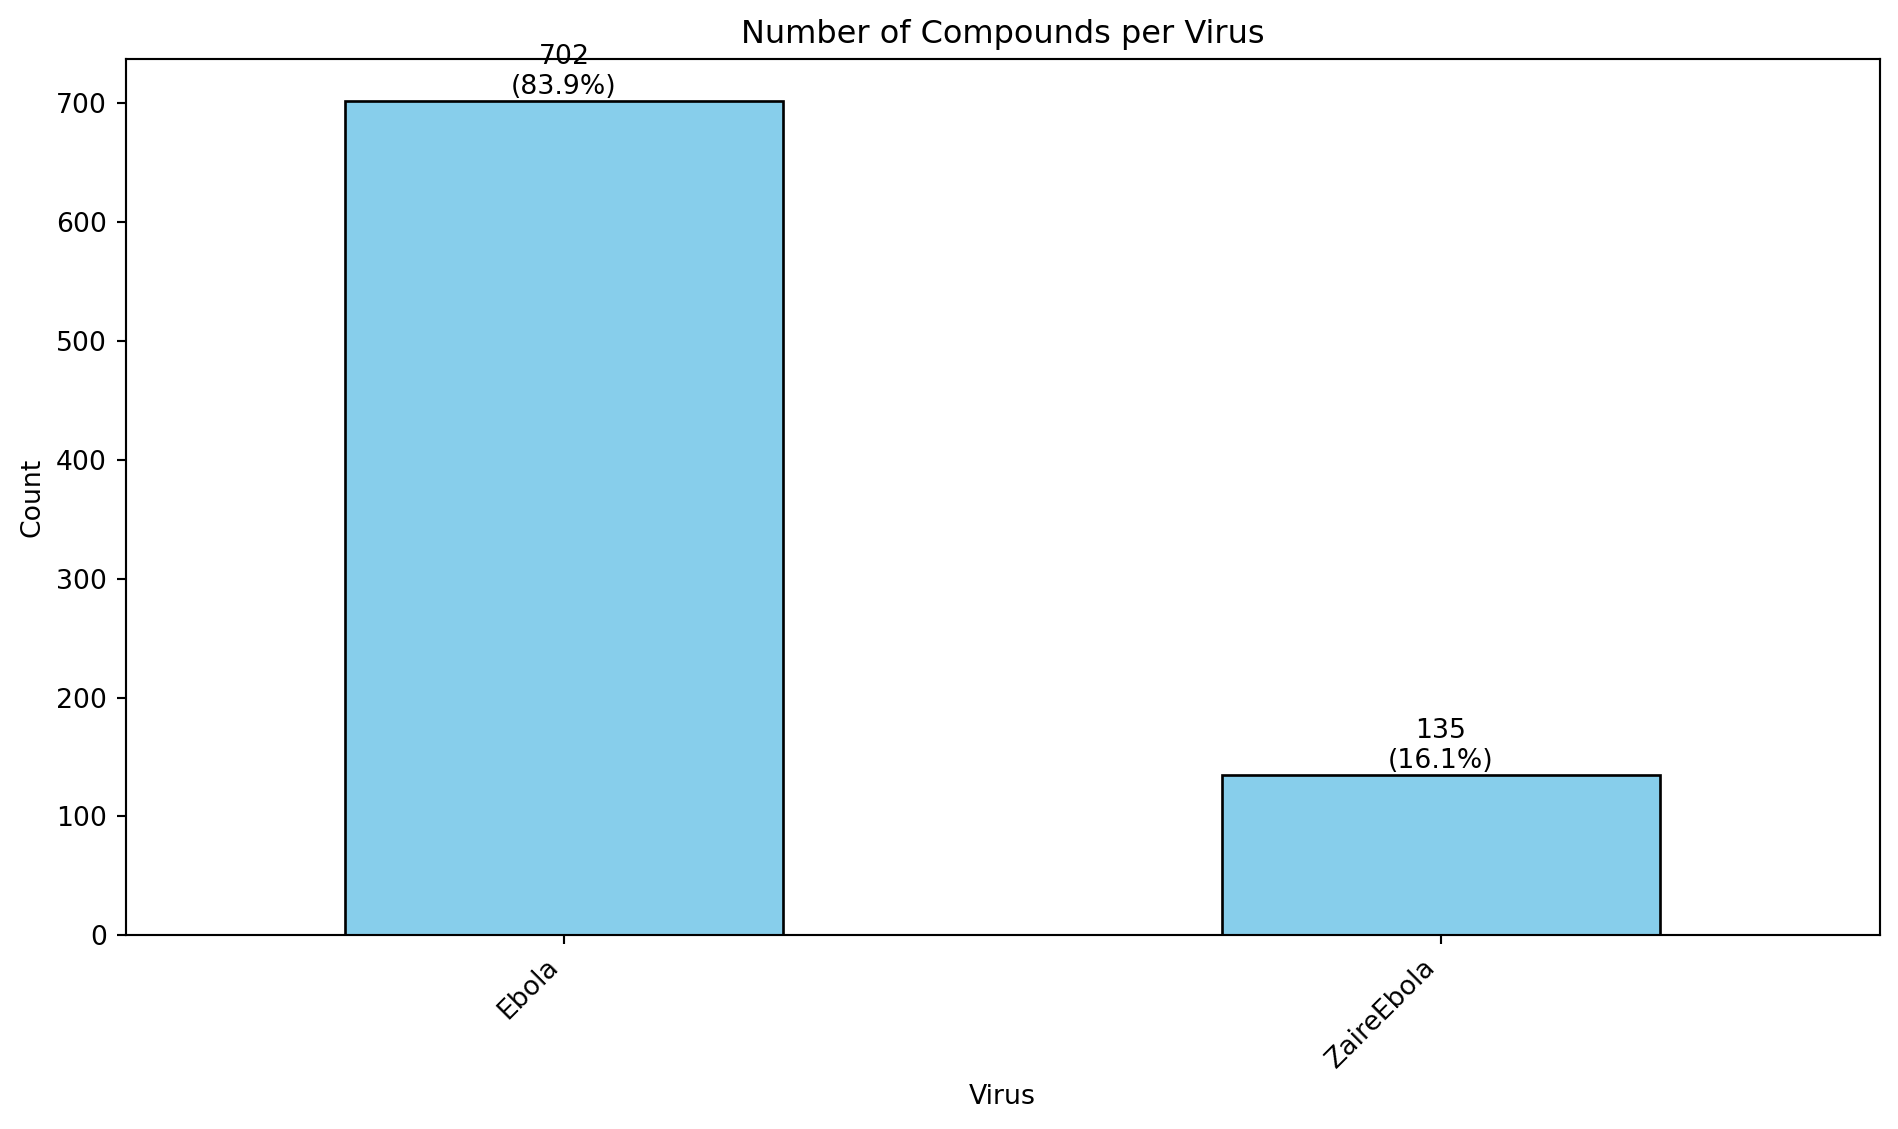

In [132]:
# Get counts and percentages
counts = combinedEbolaVirusData_chEMBL['StrainClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [133]:
combinedEbolaVirusData_chEMBL.to_csv(os.path.join(modelBuildingDataDir, "combinedEbolaVirusData_chEMBL_MLready.csv"), index=False)

### pPotency value distribution across each Virus

In [134]:
combinedEbolaVirusData_chEMBL_ordered = combinedEbolaVirusData_chEMBL.sort_values(by='StrainClassifier')
combinedEbolaVirusData_chEMBL_ordered.head()

,ID,compound_id,Smiles,pPotency,StrainClassifier,pPotency_category
13073,1,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,4.0000,Ebola,3-10
13554,465,CHEMBL5290974,COC(=O)[C@H]1C[C@H](OCCN)[C@@H](O[C@H]2O[C@H](...,3.2076,Ebola,3-10
13555,466,CHEMBL5287023,CCN(CC)Cc1cc(Nc2c(Oc3ccccc3)cnc3cc(Cl)ccc23)ccc1O,6.1367,Ebola,3-10
13556,467,CHEMBL809,CN[C@H]1CC[C@@H](c2ccc(Cl)c(Cl)c2)c2ccccc21,5.5045,Ebola,3-10
13557,468,CHEMBL809,CN[C@H]1CC[C@@H](c2ccc(Cl)c(Cl)c2)c2ccccc21,5.8416,Ebola,3-10


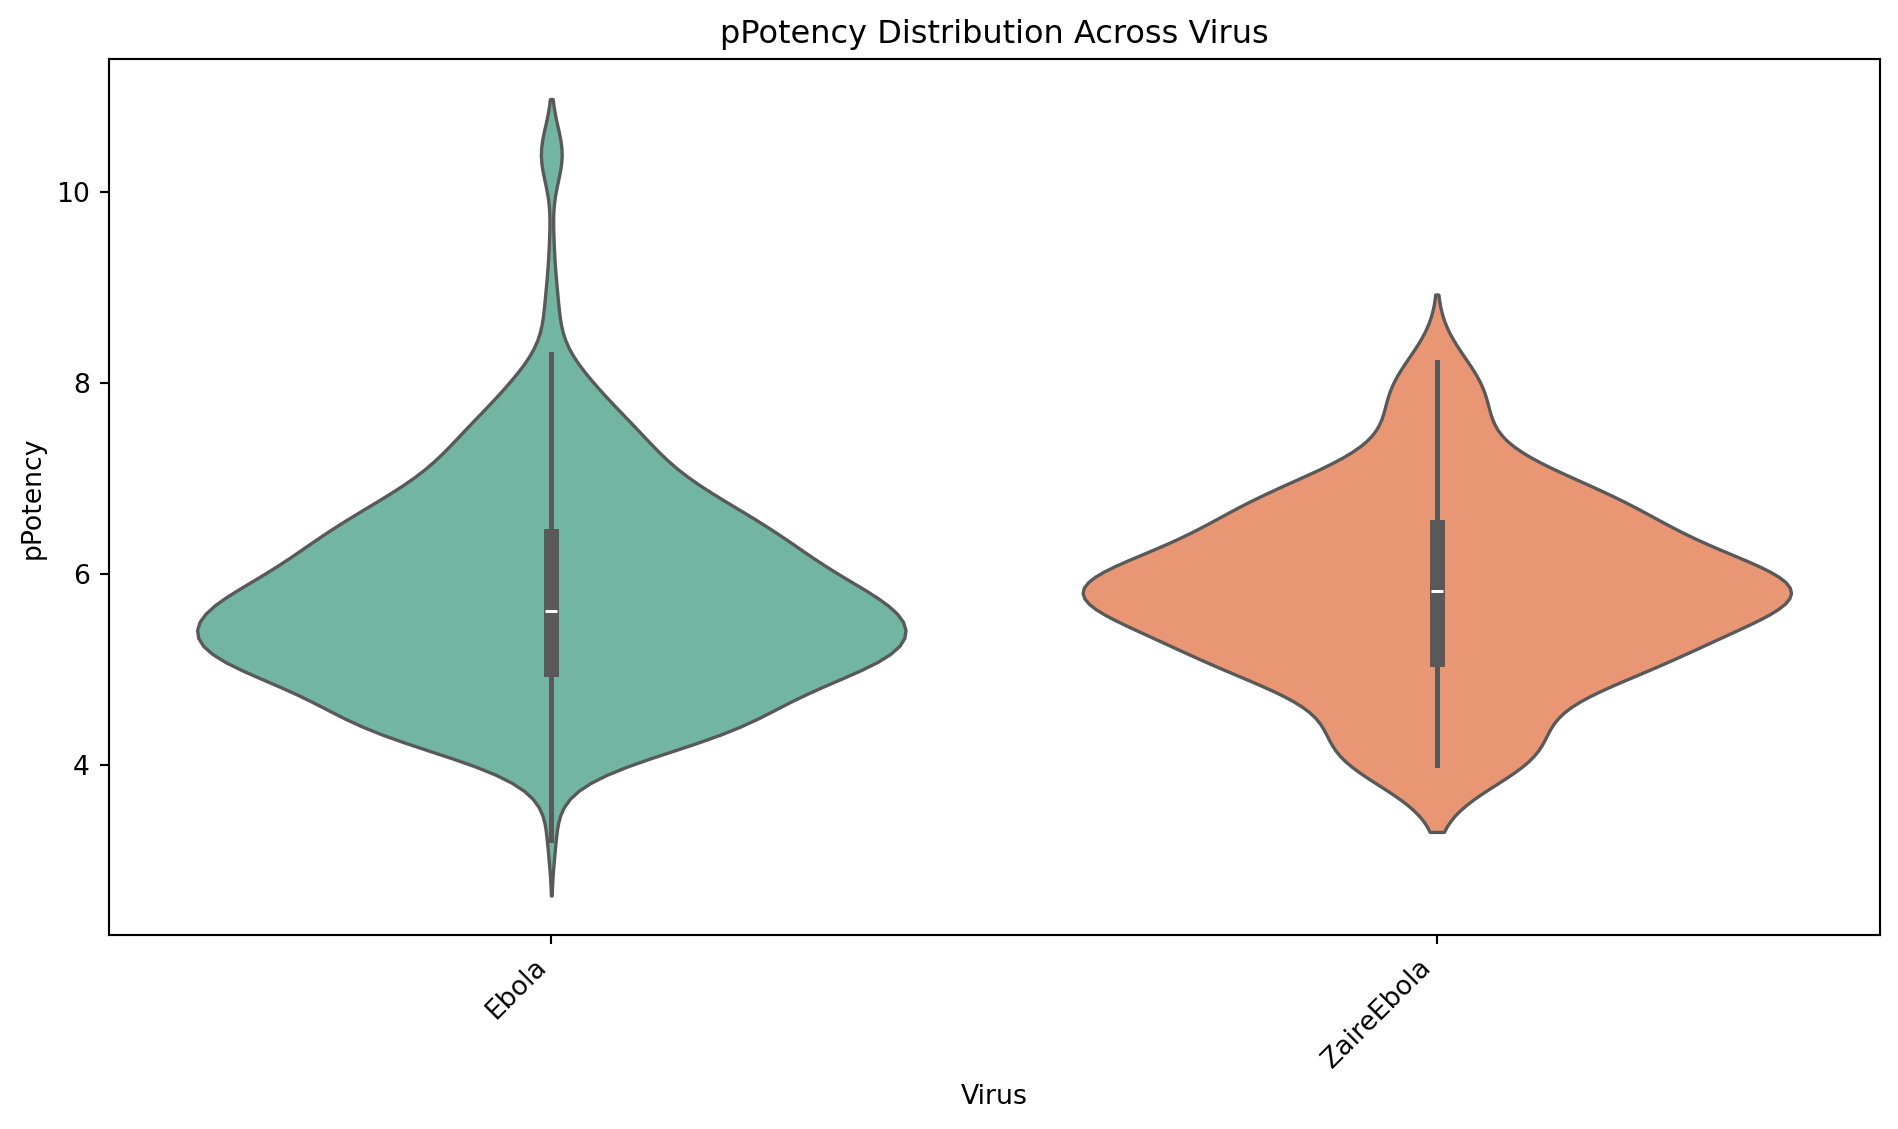

In [135]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=combinedEbolaVirusData_chEMBL_ordered,
    x='StrainClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

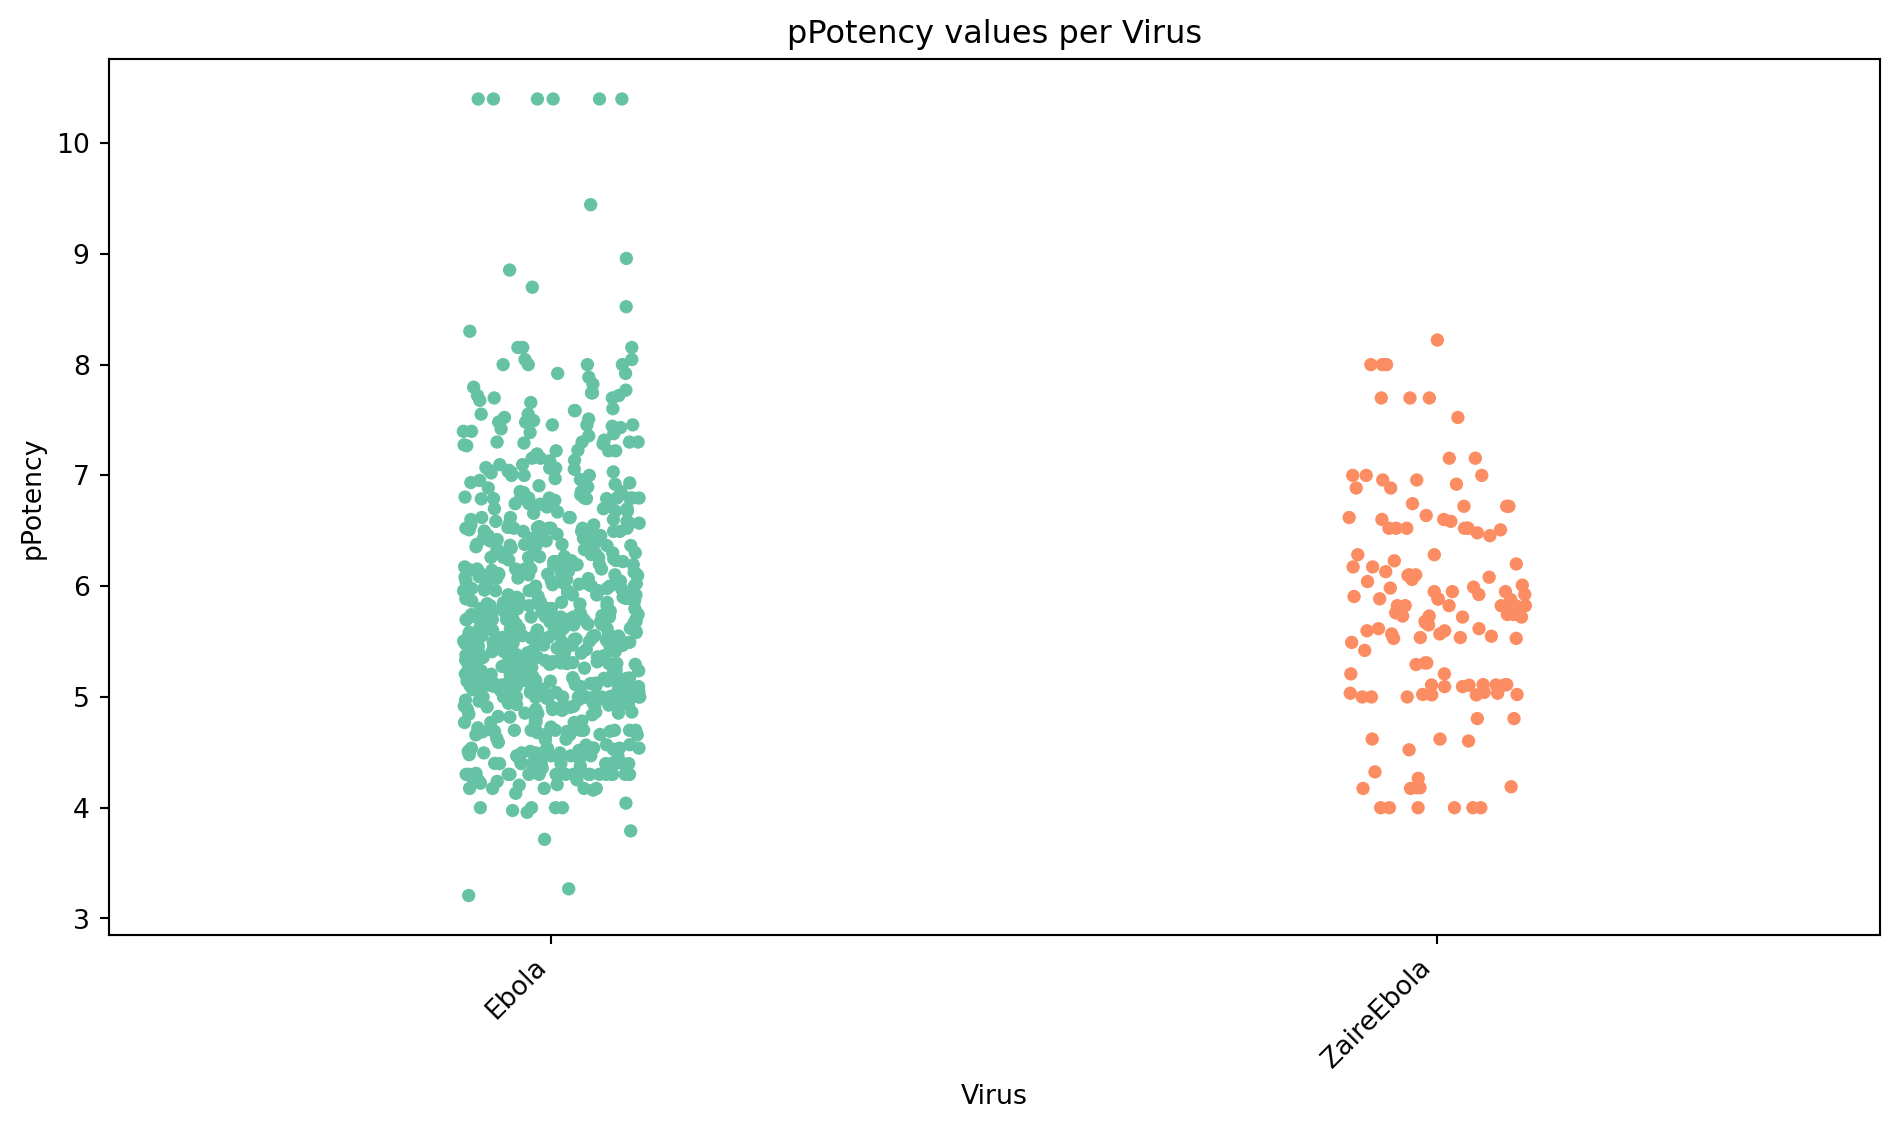

In [136]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=combinedEbolaVirusData_chEMBL_ordered,
    x='StrainClassifier',
    y='pPotency',
    jitter=True,          # spreads the dots to avoid overlap
    palette='Set2',
    alpha=1
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency values per Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Create MACAW embeedings to run ART

In [137]:
# ---------------------------
# 1. FIT MACAW AND GENERATE EMBEDDINGS
# ---------------------------
# Initialize MACAW
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=45, 
    n_landmarks=750, 
    random_state=42
)

# Fit MACAW on SMILES and pPotency
mcw.fit(combinedEbolaVirusData_chEMBL['Smiles'], combinedEbolaVirusData_chEMBL['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(modelBuildingDataDir, "combinedEbolaVirusData_chEMBL_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(combinedEbolaVirusData_chEMBL['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=combinedEbolaVirusData_chEMBL.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
combinedEbolaVirusData_chEMBL_wMACAW = pd.concat([combinedEbolaVirusData_chEMBL, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {combinedEbolaVirusData_chEMBL.shape}")
print(f"New dataframe shape: {combinedEbolaVirusData_chEMBL_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
combinedEbolaVirusData_chEMBL_wMACAW

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/combinedEbolaVirusData_chEMBL_MACAW_transformer.joblib
MACAW embeddings shape: (837, 45)

Original dataframe shape: (837, 6)
New dataframe shape: (837, 51)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45']


,ID,compound_id,Smiles,pPotency,StrainClassifier,pPotency_category,MACAW_1,MACAW_2,MACAW_3,MACAW_4,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
13073,1,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,4.0000,Ebola,3-10,-0.1558,0.1007,-0.0799,-0.0835,...,-0.1034,0.0528,-0.1180,0.0470,-0.0663,0.0628,-0.0015,0.0043,-0.0744,0.0526
13074,2,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.4949,Ebola,3-10,-0.2100,0.1293,-0.1643,-0.3382,...,-0.0262,-0.0050,0.0274,-0.0386,-0.0074,-0.0263,-0.0207,-0.0166,0.0008,-0.0339
13075,3,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.7258,Ebola,3-10,0.0372,-0.1532,-0.1287,0.0913,...,0.1370,-0.0919,-0.0230,-0.0072,-0.0972,0.0349,-0.0644,0.0566,-0.0353,0.0308
13076,4,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.6038,Ebola,3-10,0.0604,-0.1517,-0.1504,0.0818,...,0.1303,-0.0948,-0.0321,0.0015,-0.0919,0.0566,-0.0552,0.0497,-0.0258,0.0072
13077,5,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,4.3010,Ebola,3-10,0.1433,-0.1804,-0.3324,0.0507,...,-0.0423,-0.0333,0.0646,0.0080,0.1987,0.0459,0.0055,-0.0047,0.0171,0.0087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,833,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840,ZaireEbola,3-10,-0.0145,-0.0682,0.0952,-0.0034,...,0.0764,-0.0234,-0.0351,-0.1566,0.0225,0.0105,0.0189,-0.0412,0.0243,-0.0949
1108,834,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.2840,ZaireEbola,3-10,-0.0145,-0.0682,0.0952,-0.0034,...,0.0764,-0.0234,-0.0351,-0.1566,0.0225,0.0105,0.0189,-0.0412,0.0243,-0.0949
1109,835,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212,ZaireEbola,3-10,-0.0519,-0.0477,0.1198,-0.0031,...,0.0141,0.0101,0.0028,0.0070,0.0497,0.0092,0.0952,0.0401,-0.0174,0.0117
1110,836,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.7212,ZaireEbola,3-10,-0.0519,-0.0477,0.1198,-0.0031,...,0.0141,0.0101,0.0028,0.0070,0.0497,0.0092,0.0952,0.0401,-0.0174,0.0117


In [138]:
combinedEbolaVirusData_chEMBL_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "combinedEbolaVirusData_chEMBL_wMACAW.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [139]:
# df = combinedEbolaVirusData_chEMBL
Y = combinedEbolaVirusData_chEMBL.pPotency
smiles = combinedEbolaVirusData_chEMBL.Smiles

In [140]:
print(len(smiles))

837


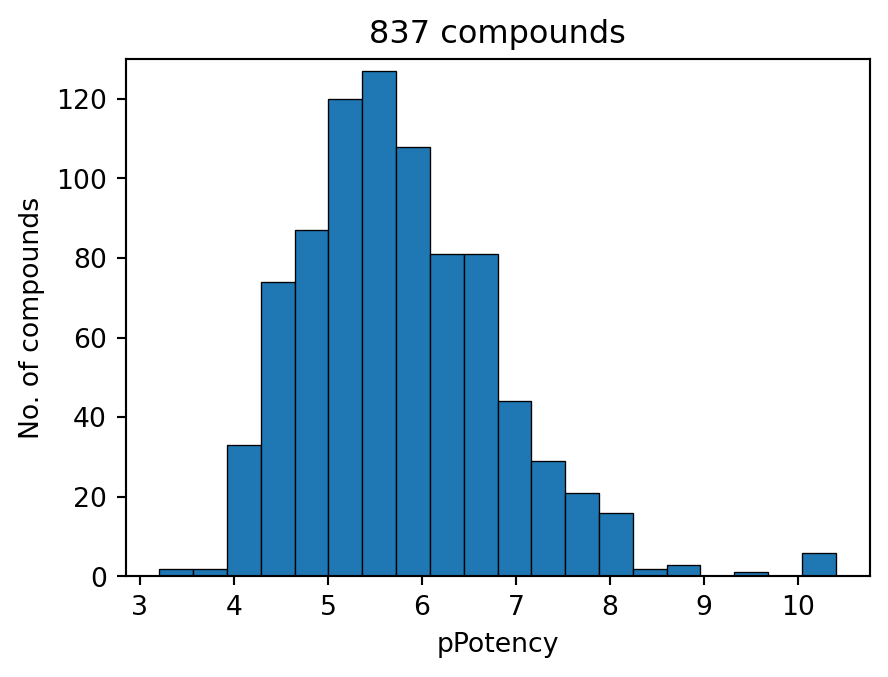

In [141]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [142]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [143]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [144]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=45, 
    n_landmarks=750, 
    random_state=42
)


After cleaning NaN values, reset the indices

In [145]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 837 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Train + Test results

In [146]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.35
  RMSE: 0.47
  R²:   0.80
Test Set:
  MAE:  0.45
  RMSE: 0.61
  R²:   0.67

Best params (sample): [{'C': 7, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 7, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 5, 'epsilon': 0.3, 'kernel': 'rbf'}]
CPU times: user 315 ms, sys: 103 ms, total: 418 ms
Wall time: 47.4 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/combinedEbolaVirus_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/combinedEbolaVirus_CV_TrTs.png


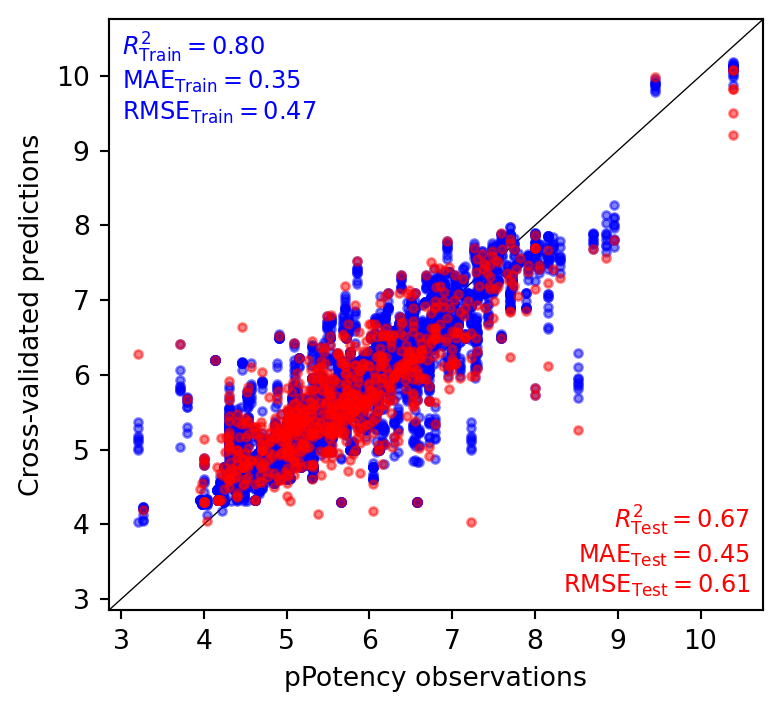

In [147]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + 'combinedEbolaVirus_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [148]:
mcw.fit(smiles, Y)

In [149]:
X_all = mcw.transform(smiles)
X_all.shape

(837, 45)

Training samples: 669
Test samples: 168
Feature dimensions: 15

Running GridSearchCV with 4 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 10
  epsilon: 0.1
  kernel: rbf

Best CV MAE (on training folds): 0.48

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.77            0.57            0.20           
MAE        0.35            0.46            0.11           
RMSE       0.51            0.65            0.14           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/combinedEbolaVirus_fullData_TrTs.svg
Saved: /mnt/data

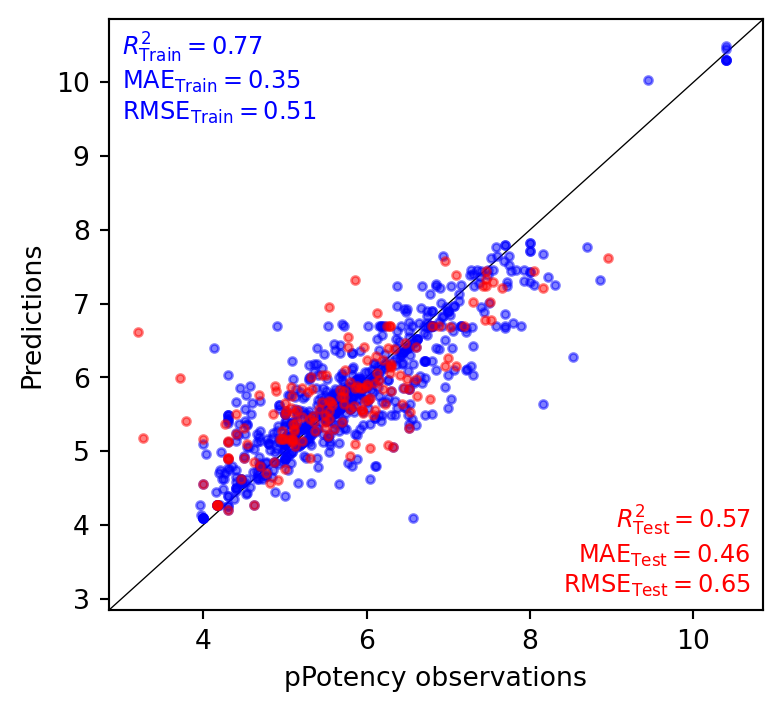

CPU times: user 2.05 s, sys: 64.6 ms, total: 2.12 s
Wall time: 5.54 s


In [150]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)

# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=saveDir + 'combinedEbolaVirus_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

### Compare performance of different ML model

- SVR
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Neural Network

Import all necessary libraries

### Use ART to get predictions

## 2.1 Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

### Create a list of data frames of buyable antivirals

In [151]:
EnamineAntiviralsData = pd.read_csv(dataDir + "Enamine/Enamine_Antiviral_Library_plated_3200cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                    skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntiviralsData.shape}")

smiles_train = combinedEbolaVirusData_chEMBL_wMACAW.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntiviralsData['Canonical_SMILES'] = EnamineAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntiviralsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntiviralsData_filtered = EnamineAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntiviralsData = EnamineAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntiviralsData.shape}")
print(f"Removed {EnamineAntiviralsData.shape[0] - EnamineAntiviralsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib_EnamineDataset = EnamineAntiviralsData.SMILES
EnamineAntiviralsData['source_DataBase'] = 'Enamine_Antivirals'
needed_cols = ['SMILES', 'source_DataBase']
EnamineAntiviralsData = EnamineAntiviralsData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_EnamineDataset)}")
EnamineAntiviralsData.head()

Original Enamine data shape: (3200, 11)
Number of unique SMILES in training set: 539
Filtered Enamine data shape for validation: (3200, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 3200


,SMILES,source_DataBase
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,Enamine_Antivirals
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,Enamine_Antivirals
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,Enamine_Antivirals
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,Enamine_Antivirals
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,Enamine_Antivirals


In [152]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Merged_Antiviral_Screening_Superset.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntiviralsData_superset = pd.DataFrame(records)
print(f"Original LifeChemicals data shape: {LCAntiviralsData_superset.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntiviralsData_superset['Canonical_SMILES'] = LCAntiviralsData_superset['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntiviralsData_superset['Canonical_SMILES'].isin(canonical_train)
LCAntiviralsData_superset_filtered = LCAntiviralsData_superset[mask].copy()

# Remove the helper column if you don't need it
LCAntiviralsData_superset = LCAntiviralsData_superset_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntiviralsData_superset.shape}")
print(f"Removed {LCAntiviralsData_superset_filtered.shape[0] - LCAntiviralsData_superset.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib_LCAntiviralsData = LCAntiviralsData_superset.SMILES
LCAntiviralsData_superset['source_DataBase'] = 'LifeChemicals_Antivirals'
needed_cols = ['SMILES', 'source_DataBase']
LCAntiviralsData_superset = LCAntiviralsData_superset[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_LCAntiviralsData)}")
LCAntiviralsData_superset.head()

Original LifeChemicals data shape: (45573, 17)
Number of unique SMILES in training set: 539
Filtered LifeChemicals data shape for validation: (45573, 17)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 45573


,SMILES,source_DataBase
0,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1,LifeChemicals_Antivirals
1,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2,LifeChemicals_Antivirals
2,CN1CCCN(Cc2ccncc2)CC1,LifeChemicals_Antivirals
3,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1,LifeChemicals_Antivirals
4,c1cc(N(C2CCNCC2)C2CC2)ncn1,LifeChemicals_Antivirals


In [153]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antiviral-Library-64958.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiviralsData = pd.DataFrame(records)
print(f"Original ChemDiv data shape: {ChemDivAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiviralsData['Canonical_SMILES'] = ChemDivAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiviralsData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiviralsData_filtered = ChemDivAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiviralsData = ChemDivAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiviralsData.shape}")
print(f"Removed {ChemDivAntiviralsData_filtered.shape[0] - ChemDivAntiviralsData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib_ChemDivAntiviralsData = ChemDivAntiviralsData.SMILES
ChemDivAntiviralsData['source_DataBase'] = 'ChemDiv_Antivirals'
needed_cols = ['SMILES', 'source_DataBase']
ChemDivAntiviralsData = ChemDivAntiviralsData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_ChemDivAntiviralsData)}")
ChemDivAntiviralsData

Original ChemDiv data shape: (64958, 28)
Number of unique SMILES in training set: 539
Filtered ChemDiv data shape for validation: (64957, 28)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 64957


,SMILES,source_DataBase
0,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,ChemDiv_Antivirals
1,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,ChemDiv_Antivirals
2,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,ChemDiv_Antivirals
3,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,ChemDiv_Antivirals
4,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,ChemDiv_Antivirals
...,...,...
64953,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,ChemDiv_Antivirals
64954,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,ChemDiv_Antivirals
64955,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,ChemDiv_Antivirals
64956,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,ChemDiv_Antivirals


In [154]:
%%time

# Concatenate in chunks and free memory 
DF_list = [
    EnamineAntiviralsData,
    LCAntiviralsData_superset,
    ChemDivAntiviralsData,
]

Ebola_all_Buyable_AntiVirals = pd.concat(DF_list, ignore_index=True)

# Free memory from individual dataframes
del EnamineAntiviralsData
del LCAntiviralsData_superset
del ChemDivAntiviralsData
gc.collect()

print(f"Total molecules before deduplication: {len(Ebola_all_Buyable_AntiVirals)}")

# Batch canonicalize SMILES using vectorized approach
def canonicalize_smiles_batch(smiles_series, batch_size=50000):
    results = []
    for i in range(0, len(smiles_series), batch_size):
        batch = smiles_series.iloc[i:i + batch_size]
        canonical = []
        for smi in batch:
            try:
                mol = Chem.MolFromSmiles(smi)
                if mol is not None:
                    canonical.append(Chem.MolToSmiles(mol))
                else:
                    canonical.append(None)
            except:
                canonical.append(None)
        results.extend(canonical)
        print(f"  Processed {min(i + batch_size, len(smiles_series))}/{len(smiles_series)} SMILES...")
        gc.collect()
    return results

print("Canonicalizing SMILES...")
Ebola_all_Buyable_AntiVirals['SMILES'] = canonicalize_smiles_batch(Ebola_all_Buyable_AntiVirals['SMILES'])

# Drop invalid and duplicate SMILES
Ebola_all_Buyable_AntiVirals = Ebola_all_Buyable_AntiVirals.dropna(subset=['SMILES'])
Ebola_all_Buyable_AntiVirals = Ebola_all_Buyable_AntiVirals.drop_duplicates(subset='SMILES', keep='first')
Ebola_all_Buyable_AntiVirals = Ebola_all_Buyable_AntiVirals.reset_index(drop=True)
gc.collect()

print(f"Total molecules after deduplication: {len(Ebola_all_Buyable_AntiVirals)}")

# save to a file path string
output_path = saveDir + "Ebola_all_Buyable_AntiVirals.csv"
Ebola_all_Buyable_AntiVirals.to_csv(output_path, index=False, encoding="utf-8")
print(f"Saved to {output_path}")

Ebola_all_Buyable_AntiVirals

Total molecules before deduplication: 113730
Canonicalizing SMILES...
  Processed 50000/113730 SMILES...
  Processed 100000/113730 SMILES...
  Processed 113730/113730 SMILES...
Total molecules after deduplication: 113185
Saved to /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_all_Buyable_AntiVirals.csv
CPU times: user 47.8 s, sys: 64 ms, total: 47.9 s
Wall time: 47.9 s


,SMILES,source_DataBase
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,Enamine_Antivirals
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,Enamine_Antivirals
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,Enamine_Antivirals
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,Enamine_Antivirals
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,Enamine_Antivirals
...,...,...
113180,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,ChemDiv_Antivirals
113181,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,ChemDiv_Antivirals
113182,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,ChemDiv_Antivirals
113183,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,ChemDiv_Antivirals


### Generate `MACAW` embeedings for all buyable molecules --> to run external validation with `ART`

In [155]:
# ---------------------------
# 1. LOAD MACAW TRANSFORMER AND GENERATE EMBEDDINGS
# ---------------------------
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(modelBuildingDataDir, "combinedEbolaVirusData_chEMBL_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(Ebola_all_Buyable_AntiVirals['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=Ebola_all_Buyable_AntiVirals.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
Ebola_all_Buyable_AntiVirals_wMACAW = pd.concat([Ebola_all_Buyable_AntiVirals, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {Ebola_all_Buyable_AntiVirals.shape}")
print(f"New dataframe shape: {Ebola_all_Buyable_AntiVirals_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
Ebola_all_Buyable_AntiVirals_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "Ebola_all_Buyable_AntiVirals_wMACAW.csv"), index=False)
Ebola_all_Buyable_AntiVirals_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/combinedEbolaVirusData_chEMBL_MACAW_transformer.joblib
50000
Partition 4/10
  Fold 4 - Train MAE: 0.36, Test MAE: 0.43
Partition 7/10
  Fold 7 - Train MAE: 0.35, Test MAE: 0.55
Partition 2/10
  Fold 2 - Train MAE: 0.34, Test MAE: 0.45
Partition 8/10
  Fold 8 - Train MAE: 0.34, Test MAE: 0.42
Partition 1/10
  Fold 1 - Train MAE: 0.35, Test MAE: 0.43
Partition 6/10
  Fold 6 - Train MAE: 0.36, Test MAE: 0.41
Partition 10/10
  Fold 10 - Train MAE: 0.35, Test MAE: 0.48
Partition 3/10
  Fold 3 - Train MAE: 0.36, Test MAE: 0.42
Partition 5/10
  Fold 5 - Train MAE: 0.35, Test MAE: 0.46
Partition 9/10
  Fold 9 - Train MAE: 0.33, Test MAE: 0.49
100000
MACAW embeddings shape: (113185, 45)

Original dataframe shape: (113185, 2)
New dataframe shape: (113185, 47)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACA

,SMILES,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,Enamine_Antivirals,-0.1000,0.1246,-0.0717,-0.0321,0.0209,-0.0262,-0.0000,0.0387,...,0.0128,0.0289,-0.0059,-0.0278,-0.0025,-0.0136,0.0164,-0.0103,0.0212,-0.0037
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,Enamine_Antivirals,-0.0858,0.1052,0.0033,-0.0506,-0.0357,-0.0134,-0.0166,0.0184,...,0.0549,-0.0044,-0.0220,-0.0706,-0.0030,0.0292,-0.0235,0.0201,-0.0057,-0.0035
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,Enamine_Antivirals,-0.0284,0.1203,0.0453,0.0000,0.0184,0.0641,-0.0221,-0.0050,...,0.0590,0.0216,-0.0051,-0.0453,0.0398,-0.0119,0.0115,0.0251,0.0651,0.0571
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,Enamine_Antivirals,-0.0340,0.1596,-0.0007,0.0169,-0.0017,-0.0047,-0.0543,-0.0169,...,0.0516,0.0034,-0.0523,0.0226,0.0129,-0.0235,-0.0344,0.0082,0.0093,0.0119
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,Enamine_Antivirals,-0.0272,0.1026,0.0513,-0.0019,-0.0524,0.0483,-0.0111,0.0152,...,0.0441,-0.0070,-0.0324,-0.0144,0.0075,-0.0051,0.0059,0.0014,0.0096,0.0045


### Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [156]:
Ebola_all_Buyable_AntiVirals_wARTprediction = pd.read_csv(ARTresultsDir + 'combinedEbolaVirus_wART_EnamineDataset_predicted_all.csv')
max_val = Ebola_all_Buyable_AntiVirals_wARTprediction['pPotency_prediction'].max()
min_val = Ebola_all_Buyable_AntiVirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Ebola_all_Buyable_AntiVirals_wARTprediction

pPotency_prediction range: 4.220 → 6.778


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,4.8043,0.6166,3.5959,6.0127,0.0000,0.0000,0.0003
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,4.8428,0.6130,3.6412,6.0443,0.0000,0.0000,0.0002
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,4.4648,0.6092,3.2709,5.6588,0.0000,0.0000,0.0005
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,4.8622,0.6135,3.6597,6.0647,0.0000,0.0000,0.0002
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,4.8227,0.6117,3.6238,6.0216,0.0000,0.0000,0.0002
...,...,...,...,...,...,...,...,...
113180,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,5.8841,0.6087,4.6910,7.0772,0.0000,0.0000,0.0000
113181,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,5.7450,0.6094,4.5506,6.9394,0.0000,0.0000,0.0000
113182,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,5.6811,0.6093,4.4869,6.8752,0.0000,0.0000,0.0000
113183,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,5.6705,0.6096,4.4757,6.8654,0.0000,0.0000,0.0000


### Extract `pPotency` predictions

In [157]:
predicted_pPotency = Ebola_all_Buyable_AntiVirals_wARTprediction['pPotency_prediction'].values

### Filter out `top 20` compounds with higher `pPotency`

In [158]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]  # Last (20th) value
highest_pPotency = predicted_pPotency[top_20_idx[0]]   # First (1st) value

# Convert to IC50 in µM
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} - {highest_pPotency:.2f}; IC50 --> {cutoff_IC50_uM:.3f} - {best_IC50_uM:.4f} µM")

Top 20 compounds cutoff pPotency: 6.54 (IC50: 0.2887 µM)
Highest predicted pPotency: 6.78 (IC50: 0.1667 µM)
pPotency range of top 20 compounds: pPotency --> 6.54 - 6.78; IC50 --> 0.289 - 0.1667 µM


In [159]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Create dataframe with top 20
Ebola_all_Buyable_AntiVirals_wARTprediction_top20 = Ebola_all_Buyable_AntiVirals_wARTprediction.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
Ebola_all_Buyable_AntiVirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)

# Add IC50 column in micromolar (µM)
# IC50 (µM) = 10^(-pPotency) * 1e6
Ebola_all_Buyable_AntiVirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6

# Add rank column at the beginning
Ebola_all_Buyable_AntiVirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = predicted_pPotency[top_20_idx[0]]   # Highest (best)
pPotency_min = predicted_pPotency[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min_uM = 10**(-pPotency_max) * 1e6            # Lowest IC50 (most potent)
IC50_max_uM = 10**(-pPotency_min) * 1e6            # Highest IC50 (least potent in top 20)

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max_uM:.4f} µM")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min_uM:.4f} µM")

print("\nRange for Top 20 Compounds:")
print(f"pPotency Range:   {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"IC50 Range (µM):  {IC50_max_uM:.4f} - {IC50_min_uM:.4f}")

# Set pandas display options
pd.options.display.float_format = lambda x: f'{x:.4f}'

# Display the dataframe
Ebola_all_Buyable_AntiVirals_wARTprediction_top20 = Ebola_all_Buyable_AntiVirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Ebola_all_Buyable_AntiVirals_wARTprediction_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.540
  IC50:        0.2887 µM

Best Values (1st ranked compound):
  pPotency:    6.778
  IC50:        0.1667 µM

Range for Top 20 Compounds:
pPotency Range:   6.540 - 6.778
IC50 Range (µM):  0.2887 - 0.1667


,Rank,SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
47532,1,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,6.7780,0.6116,0.1667
91293,2,CCC(=C(c1ccc(OC)cc1)c1ccc(OC)cc1)c1cn(CC(O)CN(...,6.7720,0.6095,0.1690
98555,3,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,6.7650,0.6131,0.1716
98563,4,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,6.7110,0.6132,0.1945
99293,5,CCN1CCCC1CNC(=O)c1ccc2c(c1)N(Cc1cc(C)ccc1C)C(=...,6.6870,0.6089,0.2057
82514,6,COc1ccc(C(O)(c2ccc(OC)cc2)c2ccc(CN(CCN3CCOCC3)...,6.6700,0.6075,0.2136
83404,7,CCN(C)CCN(CC)C(=O)CCc1cc2c(n1-c1ccc(C)cc1OC)-c...,6.6530,0.6084,0.2224
98626,8,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,6.6440,0.6117,0.2270
111760,9,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,6.6240,0.6125,0.2375
84996,10,CCN1CCN(S(=O)(=O)c2cc(NC(=O)C3CCCC3)ccc2Oc2c(C...,6.6080,0.6113,0.2467


In [160]:
Ebola_all_Buyable_AntiVirals_wARTprediction_top20.to_csv(os.path.join(saveDir + "Ebola_all_Buyable_AntiVirals_wARTprediction_top20.csv"), index=False)
Ebola_all_Buyable_AntiVirals_wARTprediction_top20[['SMILES']].to_csv(os.path.join(saveDir + "Ebola_all_Buyable_AntiVirals_wARTprediction_top20_SMILESonly.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_all_Buyable_AntiVirals_wARTprediction_top20_Compounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_all_Buyable_AntiVirals_wARTprediction_top20_Compounds.svg


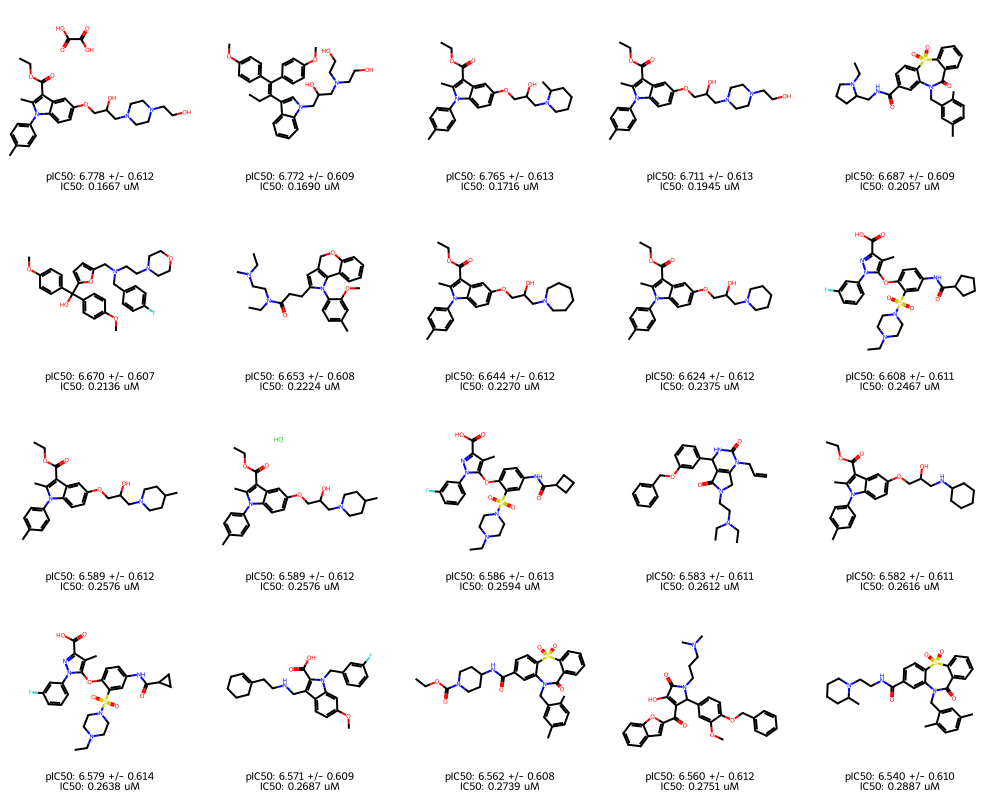

In [161]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_all_Buyable_AntiVirals_wARTprediction_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in Ebola_all_Buyable_AntiVirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'Ebola_all_Buyable_AntiVirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'Ebola_all_Buyable_AntiVirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)

### Save molecules as .gif

Saved GIF: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_all_Buyable_AntiVirals_wARTprediction_top20_Compounds.gif


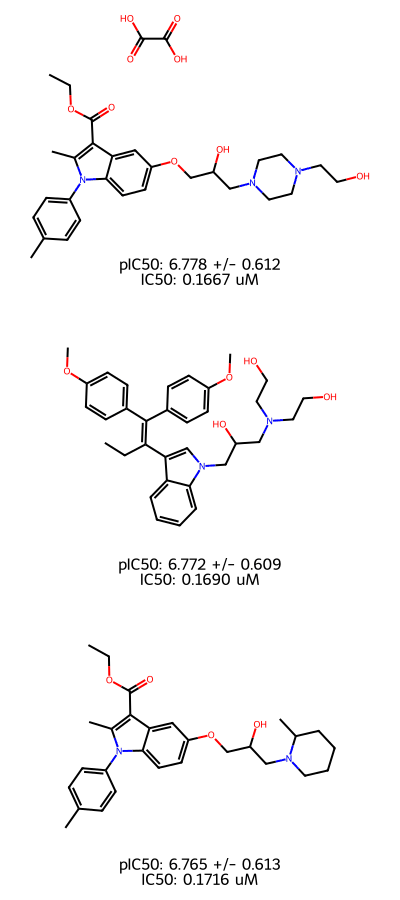

In [162]:
# Get molecules and legends
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_all_Buyable_AntiVirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_all_Buyable_AntiVirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

# Split molecules into chunks of 4 for each frame
mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]
    
    # Generate grid image: 1 column (vertical layout), 4 rows
    frame_img = Draw.MolsToGridImage(
        chunk_mols,
        subImgSize=(400, 300),
        molsPerRow=1,  # 1 per row = vertical arrangement
        useSVG=False,
        legends=chunk_legends,
        returnPNG=False
    )
    
    # Convert to RGB if necessary (GIF requires consistent mode)
    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')
    
    frames.append(frame_img)

# Save as GIF
output_gif = saveDir + 'Ebola_all_Buyable_AntiVirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=3000,  # 3 seconds per frame
    loop=0,         # 0 = infinite loop
    optimize=True
)
print(f"Saved GIF: {output_gif}")

# Display in notebook
from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [163]:
# Keep only the lookup columns (and drop duplicate SMILES to avoid row explosion)
lookupDF = (
    Ebola_all_Buyable_AntiVirals[["SMILES", "source_DataBase"]]
    .dropna(subset=["SMILES"])
    .drop_duplicates(subset=["SMILES"], keep="first")
)

# Left-merge so every prediction row is preserved; source_DataBase is appended as the last column
Ebola_all_Buyable_AntiVirals_wARTprediction_top20 = Ebola_all_Buyable_AntiVirals_wARTprediction_top20.merge(
    lookupDF,
    how="left",
    on="SMILES",
    validate="many_to_one"  # many predictions can map to one SMILES in lookup
)

Ebola_all_Buyable_AntiVirals_wARTprediction_top20

,Rank,SMILES,pPotency_prediction,pPotency_std,IC50 (µM),source_DataBase
0,1,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,6.7780,0.6116,0.1667,LifeChemicals_Antivirals
1,2,CCC(=C(c1ccc(OC)cc1)c1ccc(OC)cc1)c1cn(CC(O)CN(...,6.7720,0.6095,0.1690,ChemDiv_Antivirals
2,3,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,6.7650,0.6131,0.1716,ChemDiv_Antivirals
3,4,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,6.7110,0.6132,0.1945,ChemDiv_Antivirals
4,5,CCN1CCCC1CNC(=O)c1ccc2c(c1)N(Cc1cc(C)ccc1C)C(=...,6.6870,0.6089,0.2057,ChemDiv_Antivirals
5,6,COc1ccc(C(O)(c2ccc(OC)cc2)c2ccc(CN(CCN3CCOCC3)...,6.6700,0.6075,0.2136,ChemDiv_Antivirals
6,7,CCN(C)CCN(CC)C(=O)CCc1cc2c(n1-c1ccc(C)cc1OC)-c...,6.6530,0.6084,0.2224,ChemDiv_Antivirals
7,8,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,6.6440,0.6117,0.2270,ChemDiv_Antivirals
8,9,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,6.6240,0.6125,0.2375,ChemDiv_Antivirals
9,10,CCN1CCN(S(=O)(=O)c2cc(NC(=O)C3CCCC3)ccc2Oc2c(C...,6.6080,0.6113,0.2467,ChemDiv_Antivirals


# <span style="color: #1e88e5;">Load <code>DORANET</code> generated molecules data</span>

### Import all compounds generated by `DORAnet` from `Inosine` only (gen=3) --> Possible `Antivirals`

In [164]:
InosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "InosineDORAnetGeneratedMolecules_gen3.csv", dtype=str)
print(f"Loaded {len(InosineOnly_DORAnetGenerated)} molecules")
InosineOnly_DORAnetGenerated

Loaded 4728 molecules


,SMILES,Is_Starter,SourceDirectories
0,C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H...,True,InosineOnly_gen3
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3
...,...,...,...
4723,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](...,False,InosineOnly_gen3
4724,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H]...,False,InosineOnly_gen3
4725,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H]...,False,InosineOnly_gen3
4726,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H...,False,InosineOnly_gen3


### Import all compounds generated by `DORAnet` from `Adenosine` only (gen=3) --> Possible `Antivirals`

In [165]:
AdenosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "AdenosineDORAnetGeneratedMolecules_gen3.csv", dtype=str)
print(f"Loaded {len(AdenosineOnly_DORAnetGenerated)} molecules")
AdenosineOnly_DORAnetGenerated['SourceDirectories'] = 'AdenosineOnly_gen3'
AdenosineOnly_DORAnetGenerated

Loaded 5283 molecules


,SMILES,Is_Starter,SourceDirectories
0,C1=NC(=C2C(=N1)N(C=N2)[C@H]3[C@@H]([C@@H]([C@H...,True,AdenosineOnly_gen3
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,AdenosineOnly_gen3
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,AdenosineOnly_gen3
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,AdenosineOnly_gen3
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,AdenosineOnly_gen3
...,...,...,...
5278,Nc1nc2nc3c1ncn3[C@@H]1O[C@H](C(N)O)[C@@H](O)[C...,False,AdenosineOnly_gen3
5279,O=C1Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,False,AdenosineOnly_gen3
5280,Nc1ncnc2c1ncn2[C@@H]1O[C@H](C(N)O)[C@@H](O)[C@...,False,AdenosineOnly_gen3
5281,CNC(=O)[C@H]1O[C@@H](n2cnc3c(N)ncnc32)[C@H](O)...,False,AdenosineOnly_gen3


### Import all compounds generated by `DORAnet` from `Guanosine` only (gen=3) --> Possible `Antivirals`

In [166]:
GuanosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "GuanosineDORAnetGeneratedMolecules_gen3.csv", dtype=str)
print(f"Loaded {len(GuanosineOnly_DORAnetGenerated)} molecules")
GuanosineOnly_DORAnetGenerated

Loaded 6186 molecules


,SMILES,Is_Starter,SourceDirectories
0,C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O...,True,GuanosineOnly_gen3
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,GuanosineOnly_gen3
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,GuanosineOnly_gen3
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,GuanosineOnly_gen3
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,GuanosineOnly_gen3
...,...,...,...
6181,Nc1nc2c(ncn2[C@@H]2O[C@H](C(N)O)[C@@H](O)[C@H]...,False,GuanosineOnly_gen3
6182,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C...,False,GuanosineOnly_gen3
6183,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C...,False,GuanosineOnly_gen3
6184,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[...,False,GuanosineOnly_gen3


### Import all compounds generated by `DORAnet` from `Xanthosine` only (gen=3) --> Possible `Antivirals`

In [167]:
XanthosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "XanthosineDORAnetGeneratedMolecules_gen3.csv", dtype=str)
print(f"Loaded {len(XanthosineOnly_DORAnetGenerated)} molecules")
XanthosineOnly_DORAnetGenerated

Loaded 4355 molecules


,SMILES,Is_Starter,SourceDirectories
0,C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O...,True,XanthosineOnly_gen3
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,XanthosineOnly_gen3
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,XanthosineOnly_gen3
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,XanthosineOnly_gen3
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,XanthosineOnly_gen3
...,...,...,...
4350,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32...,False,XanthosineOnly_gen3
4351,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3
4352,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3
4353,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c...,False,XanthosineOnly_gen3


### Marge the data for all `DORAnet` generated `Antivirals` for different starter molecule

In [168]:
%%time

# Concatenate in chunks and free memory ---
DF_list = [
    InosineOnly_DORAnetGenerated,
    AdenosineOnly_DORAnetGenerated,
    GuanosineOnly_DORAnetGenerated,
    XanthosineOnly_DORAnetGenerated,
]

Ebola_allDORAnetGenerated_Antivirals = pd.concat(DF_list, ignore_index=True)

# Free memory from individual dataframes
del InosineOnly_DORAnetGenerated
del AdenosineOnly_DORAnetGenerated
del GuanosineOnly_DORAnetGenerated
del XanthosineOnly_DORAnetGenerated
gc.collect()

print(f"Total molecules before deduplication: {len(Ebola_allDORAnetGenerated_Antivirals)}")

# --- 2. Only keep needed columns early ---
#needed_cols = ['SMILES', 'Is_Starter', 'SourceDirectories', 'source_DataBase']
#Ebola_allDORAnetGenerated_Antivirals = Ebola_allDORAnetGenerated_Antivirals[needed_cols]

# --- 3. Batch canonicalize SMILES using vectorized approach ---
def canonicalize_smiles_batch(smiles_series, batch_size=50000):
    results = []
    for i in range(0, len(smiles_series), batch_size):
        batch = smiles_series.iloc[i:i + batch_size]
        canonical = []
        for smi in batch:
            try:
                mol = Chem.MolFromSmiles(smi)
                if mol is not None:
                    canonical.append(Chem.MolToSmiles(mol))
                else:
                    canonical.append(None)
            except:
                canonical.append(None)
        results.extend(canonical)
        print(f"  Processed {min(i + batch_size, len(smiles_series))}/{len(smiles_series)} SMILES...")
        gc.collect()
    return results

print("Canonicalizing SMILES...")
Ebola_allDORAnetGenerated_Antivirals['SMILES'] = canonicalize_smiles_batch(Ebola_allDORAnetGenerated_Antivirals['SMILES'])

# --- 4. Drop invalid and duplicate SMILES ---
Ebola_allDORAnetGenerated_Antivirals = Ebola_allDORAnetGenerated_Antivirals.dropna(subset=['SMILES'])
Ebola_allDORAnetGenerated_Antivirals = Ebola_allDORAnetGenerated_Antivirals.drop_duplicates(subset='SMILES', keep='first')
Ebola_allDORAnetGenerated_Antivirals = Ebola_allDORAnetGenerated_Antivirals.reset_index(drop=True)
gc.collect()

print(f"Total molecules after deduplication: {len(Ebola_allDORAnetGenerated_Antivirals)}")

# --- 5. Fix: save to a file path string, not the dataframe variable ---
output_path = DORANETmoleculesDataDir + "Ebola_allDORAnetGenerated_Antivirals.csv"
Ebola_allDORAnetGenerated_Antivirals.to_csv(output_path, index=False, encoding="utf-8")
print(f"Saved to {output_path}")

Ebola_allDORAnetGenerated_Antivirals

Total molecules before deduplication: 20552
Canonicalizing SMILES...
  Processed 20552/20552 SMILES...
Total molecules after deduplication: 20372
Saved to /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/DORAnet_molecules/Ebola_allDORAnetGenerated_Antivirals.csv
CPU times: user 8.68 s, sys: 9.62 ms, total: 8.69 s
Wall time: 8.69 s


,SMILES,Is_Starter,SourceDirectories
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,True,InosineOnly_gen3
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3
...,...,...,...
20367,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32...,False,XanthosineOnly_gen3
20368,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3
20369,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3
20370,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c...,False,XanthosineOnly_gen3


### Generate `MACAW` embeedings for `DORAnet` generated molecules --> to run external validation with `ART`

In [169]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(modelBuildingDataDir, "combinedEbolaVirusData_chEMBL_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(Ebola_allDORAnetGenerated_Antivirals['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=Ebola_allDORAnetGenerated_Antivirals.index)
Ebola_allDORAnetGenerated_Antivirals_wMACAW = pd.concat([Ebola_allDORAnetGenerated_Antivirals, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {Ebola_allDORAnetGenerated_Antivirals.shape}")
print(f"New dataframe shape: {Ebola_allDORAnetGenerated_Antivirals_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
Ebola_allDORAnetGenerated_Antivirals_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "Ebola_allDORAnetGenerated_Antivirals_wMACAW.csv"), index=False)
Ebola_allDORAnetGenerated_Antivirals_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/combinedEbolaVirusData_chEMBL_MACAW_transformer.joblib
MACAW embeddings shape: (20372, 45)

Original dataframe shape: (20372, 3)
New dataframe shape: (20372, 48)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45']


,SMILES,Is_Starter,SourceDirectories,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,True,InosineOnly_gen3,-0.1557,0.1212,-0.1586,-0.2458,0.0519,-0.0285,0.0415,...,0.0136,0.0235,0.0128,-0.0550,0.0026,-0.0098,-0.0300,-0.0035,0.0104,0.0097
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3,-0.0625,-0.0017,-0.1730,-0.0859,-0.0275,0.0017,0.0041,...,-0.0170,0.0309,-0.0321,-0.0006,-0.0390,-0.0391,0.0116,-0.0143,0.0062,0.0026
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3,-0.1228,0.0739,-0.1653,-0.1935,0.0154,-0.0082,0.0296,...,-0.0035,0.0227,-0.0054,-0.0131,-0.0112,-0.0186,-0.0023,0.0095,-0.0108,0.0055
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3,0.0621,-0.1076,-0.2269,0.0097,-0.0520,0.0321,-0.0469,...,-0.0100,0.0168,-0.0099,-0.0172,0.0142,0.0093,-0.0062,-0.0152,0.0181,-0.0079
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3,0.0721,-0.1142,-0.2189,0.0134,-0.0496,0.0314,-0.0519,...,-0.0058,0.0211,-0.0111,-0.0084,0.0153,0.0062,-0.0088,-0.0104,0.0212,-0.0056


## Read results (`SMILES` & `pPotency`) from `ART` post predictions with uncertentity

In [170]:
Ebola_allDORAnetGenerated_Antivirals_wARTprediction = pd.read_csv(ARTresultsDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv')
max_val = Ebola_allDORAnetGenerated_Antivirals_wARTprediction['pPotency_prediction'].max()
min_val = Ebola_allDORAnetGenerated_Antivirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Ebola_allDORAnetGenerated_Antivirals_wARTprediction

pPotency_prediction range: 4.619 → 5.785


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,True,InosineOnly_gen3,5.1110,0.6077,3.9198,6.3021,0.0000,0.0000,0.0001
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3,5.4128,0.6137,4.2099,6.6157,0.0000,0.0000,0.0001
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3,5.1820,0.6085,3.9894,6.3746,0.0000,0.0000,0.0001
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3,5.6681,0.6142,4.4643,6.8718,0.0000,0.0000,0.0000
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3,5.7578,0.6135,4.5553,6.9603,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...
20367,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32...,False,XanthosineOnly_gen3,5.0958,0.6083,3.9036,6.2880,0.0000,0.0000,0.0001
20368,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.0040,0.6139,3.8008,6.2072,0.0000,0.0000,0.0002
20369,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.0464,0.6129,3.8452,6.2477,0.0000,0.0000,0.0001
20370,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c...,False,XanthosineOnly_gen3,5.0790,0.6112,3.8810,6.2770,0.0000,0.0000,0.0001


In [171]:
def get_top20_range(df, group_name):
    top20 = df.nlargest(20, 'pPotency_prediction')
    best = top20.iloc[0]
    cutoff = top20.iloc[-1]
    return {
        'SourceDirectories': group_name,
        'Total Molecules': len(df),
        'pPotency Range': f"{cutoff['pPotency_prediction']:.3f} ± {cutoff['pPotency_std']:.3f} – {best['pPotency_prediction']:.3f} ± {best['pPotency_std']:.3f}",
        'IC50 (µM)': f"{best['IC50(M)_prediction'] * 1e6:.4f} – {cutoff['IC50(M)_prediction'] * 1e6:.4f}",
    }

rows = [get_top20_range(Ebola_allDORAnetGenerated_Antivirals_wARTprediction, "all Molecules")]

for source in sorted(Ebola_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'].unique()):
    subset = Ebola_allDORAnetGenerated_Antivirals_wARTprediction[
        Ebola_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'] == source
    ]
    rows.append(get_top20_range(subset, source))

Ebola_allDORAnetGenerated_Antivirals_wARTprediction_summary = pd.DataFrame(rows)
Ebola_allDORAnetGenerated_Antivirals_wARTprediction_summary

,SourceDirectories,Total Molecules,pPotency Range,IC50 (µM)
0,all Molecules,20372,5.517 ± 0.615 – 5.785 ± 0.612,1.6394 – 3.0442
1,AdenosineOnly_gen3,5229,5.441 ± 0.608 – 5.557 ± 0.611,2.7745 – 3.6264
2,GuanosineOnly_gen3,6116,5.477 ± 0.614 – 5.558 ± 0.611,2.7654 – 3.3317
3,InosineOnly_gen3,4727,5.331 ± 0.610 – 5.785 ± 0.612,1.6394 – 4.6688
4,XanthosineOnly_gen3,4300,5.313 ± 0.615 – 5.406 ± 0.609,3.9266 – 4.8607


### Filter out `top 20` compounds with higher `pPotency` from all `DORAnet` generated molecules

In [172]:
predicted_pPotency = Ebola_allDORAnetGenerated_Antivirals_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = Ebola_allDORAnetGenerated_Antivirals_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

Top 20 compounds cutoff pPotency: 5.52 ± 0.61 (IC50: 3.0442 µM)
Highest predicted pPotency: 5.79 ± 0.61 (IC50: 1.6394 µM)
pPotency range of top 20 compounds: pPotency --> 5.52 ± 0.61 - 5.79 ± 0.61; IC50 --> 3.0442 - 1.6394 µM


In [173]:
Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20 = Ebola_allDORAnetGenerated_Antivirals_wARTprediction.iloc[top_20_idx].copy()
Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20 = Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20

output_csv = os.path.join(saveDir, "Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20_SMILESonly.csv")
Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20.to_csv(output_csv, index=False)
Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20

 Saved results: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20.csv
 Saved SMILES:  /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20_SMILESonly.csv


,Rank,SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
23,1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,5.7850,0.6119,1.6394
4,2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.7580,0.6135,1.7466
25,3,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,5.7110,0.6138,1.9468
7,4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,5.6770,0.6123,2.1032
3,5,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.6680,0.6142,2.1475
22,6,*C(=O)[C@H](C)OP(=O)(O)OC[C@@H](O)[C@@H](O)[C@...,5.6520,0.6123,2.2289
21,7,*C(=O)[C@H](C)OP(=O)(O)OC[C@@H](O)[C@@H](O)[C@...,5.5760,0.6132,2.6540
17,8,*C(=O)CC[C@H](NC(=O)c1ccc(N(C=O)C[C@H]2CNc3nc(...,5.5660,0.6098,2.7153
11700,9,CC(=O)Nc1nc2c(c(=O)n1C)[n+](C)cn2[C@@H]1O[C@H]...,5.5580,0.6112,2.7654
6844,10,CC(=O)N(C(C)=O)c1ncnc2c1ncn2[C@@H]1O[C@H](C(C)...,5.5570,0.6115,2.7745


### Display molecules

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.svg


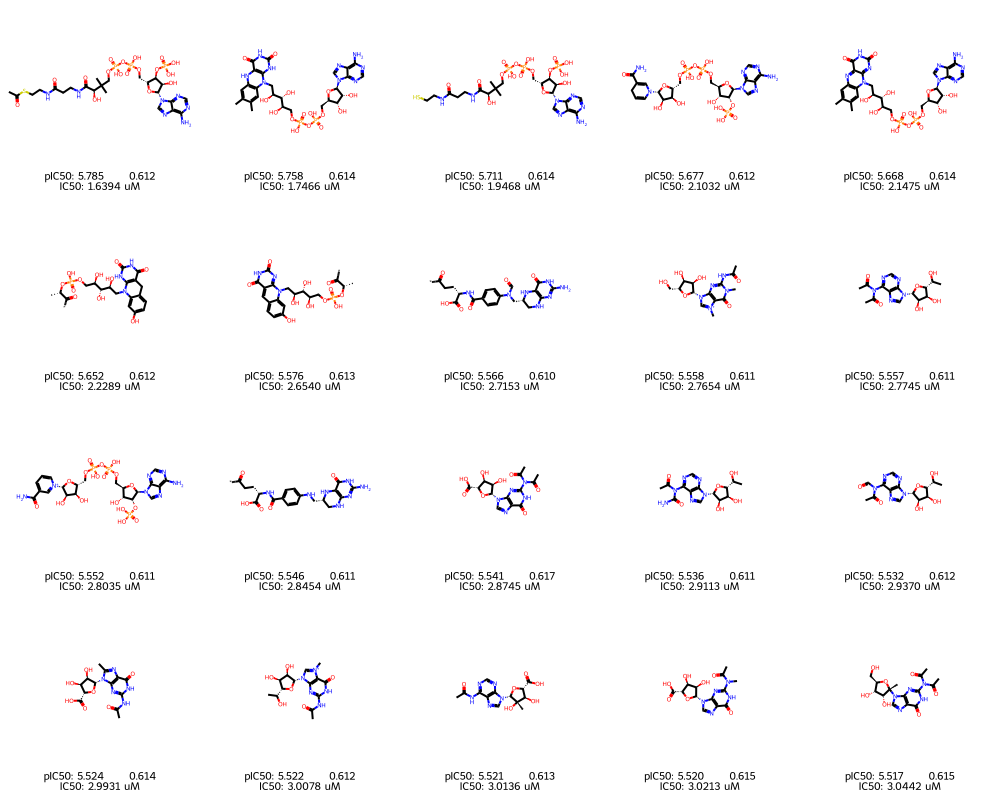

In [174]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

Saved GIF: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.gif


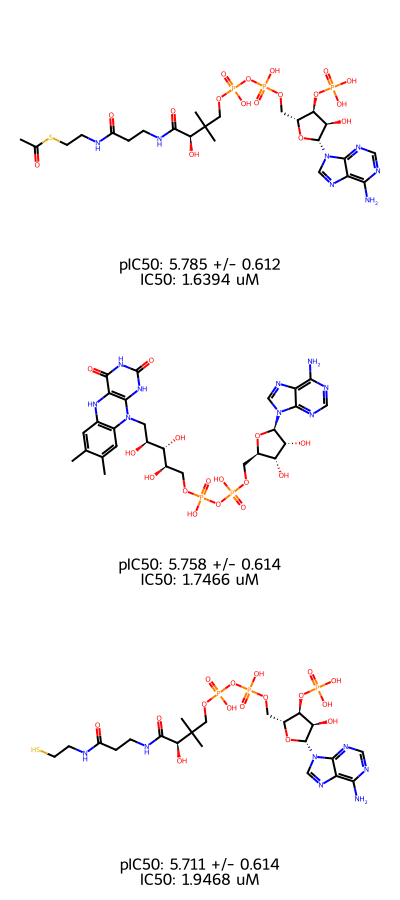

In [175]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

## Top20 potent compound generated from `Inosine` only `DORAnet` run

In [176]:
Ebola_allDORAnetGenerated_Antivirals_wARTprediction = pd.read_csv(ARTresultsDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv')

Ebola_InosineOnly_Antivirals_wARTprediction = Ebola_allDORAnetGenerated_Antivirals_wARTprediction[
    Ebola_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'] == 'InosineOnly_gen3'].reset_index(drop=True)

print(f"Total molecules: {len(Ebola_allDORAnetGenerated_Antivirals_wARTprediction)}")
print(f"DORAnet molecules generated by Inosine only: {len(Ebola_InosineOnly_Antivirals_wARTprediction)}")

max_val = Ebola_InosineOnly_Antivirals_wARTprediction['pPotency_prediction'].max()
min_val = Ebola_InosineOnly_Antivirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Ebola_InosineOnly_Antivirals_wARTprediction

Total molecules: 20372
DORAnet molecules generated by Inosine only: 4727
pPotency_prediction range: 4.651 → 5.785


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,True,InosineOnly_gen3,5.1110,0.6077,3.9198,6.3021,0.0000,0.0000,0.0001
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3,5.4128,0.6137,4.2099,6.6157,0.0000,0.0000,0.0001
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3,5.1820,0.6085,3.9894,6.3746,0.0000,0.0000,0.0001
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3,5.6681,0.6142,4.4643,6.8718,0.0000,0.0000,0.0000
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3,5.7578,0.6135,4.5553,6.9603,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...
4722,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](...,False,InosineOnly_gen3,5.1810,0.6074,3.9906,6.3715,0.0000,0.0000,0.0001
4723,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H]...,False,InosineOnly_gen3,4.9708,0.6133,3.7687,6.1729,0.0000,0.0000,0.0002
4724,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H]...,False,InosineOnly_gen3,5.0231,0.6109,3.8257,6.2204,0.0000,0.0000,0.0001
4725,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H...,False,InosineOnly_gen3,5.1311,0.6101,3.9354,6.3269,0.0000,0.0000,0.0001


### Filter out `top 20` compounds with higher `pPotency`

In [177]:
predicted_pPotency = Ebola_InosineOnly_Antivirals_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = Ebola_InosineOnly_Antivirals_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

Top 20 compounds cutoff pPotency: 5.33 ± 0.61 (IC50: 4.6688 µM)
Highest predicted pPotency: 5.79 ± 0.61 (IC50: 1.6394 µM)
pPotency range of top 20 compounds: pPotency --> 5.33 ± 0.61 - 5.79 ± 0.61; IC50 --> 4.6688 - 1.6394 µM


In [178]:
Ebola_InosineOnly_Antivirals_wARTprediction_top20 = Ebola_InosineOnly_Antivirals_wARTprediction.iloc[top_20_idx].copy()
Ebola_InosineOnly_Antivirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
Ebola_InosineOnly_Antivirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
Ebola_InosineOnly_Antivirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

Ebola_InosineOnly_Antivirals_wARTprediction_top20 = Ebola_InosineOnly_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Ebola_InosineOnly_Antivirals_wARTprediction_top20

output_csv = os.path.join(saveDir, "Ebola_InosineOnly_Antivirals_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "Ebola_InosineOnly_Antivirals_wARTprediction_top20_SMILESonly.csv")
Ebola_InosineOnly_Antivirals_wARTprediction_top20.to_csv(output_csv, index=False)
Ebola_InosineOnly_Antivirals_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

Ebola_InosineOnly_Antivirals_wARTprediction_top20

 Saved results: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_InosineOnly_Antivirals_wARTprediction_top20.csv
 Saved SMILES:  /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_InosineOnly_Antivirals_wARTprediction_top20_SMILESonly.csv


,Rank,SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
23,1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,5.7850,0.6119,1.6394
4,2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.7580,0.6135,1.7466
25,3,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,5.7110,0.6138,1.9468
7,4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,5.6770,0.6123,2.1032
3,5,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.6680,0.6142,2.1475
22,6,*C(=O)[C@H](C)OP(=O)(O)OC[C@@H](O)[C@@H](O)[C@...,5.6520,0.6123,2.2289
21,7,*C(=O)[C@H](C)OP(=O)(O)OC[C@@H](O)[C@@H](O)[C@...,5.5760,0.6132,2.6540
17,8,*C(=O)CC[C@H](NC(=O)c1ccc(N(C=O)C[C@H]2CNc3nc(...,5.5660,0.6098,2.7153
6,9,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.5520,0.6107,2.8035
18,10,*C(=O)CC[C@H](NC(=O)c1ccc(NC[C@H]2CNc3nc(N)[nH...,5.5460,0.6108,2.8454


### Display molecules

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_InosineOnly_Antivirals_wARTprediction_top20_Compounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_InosineOnly_Antivirals_wARTprediction_top20_Compounds.svg


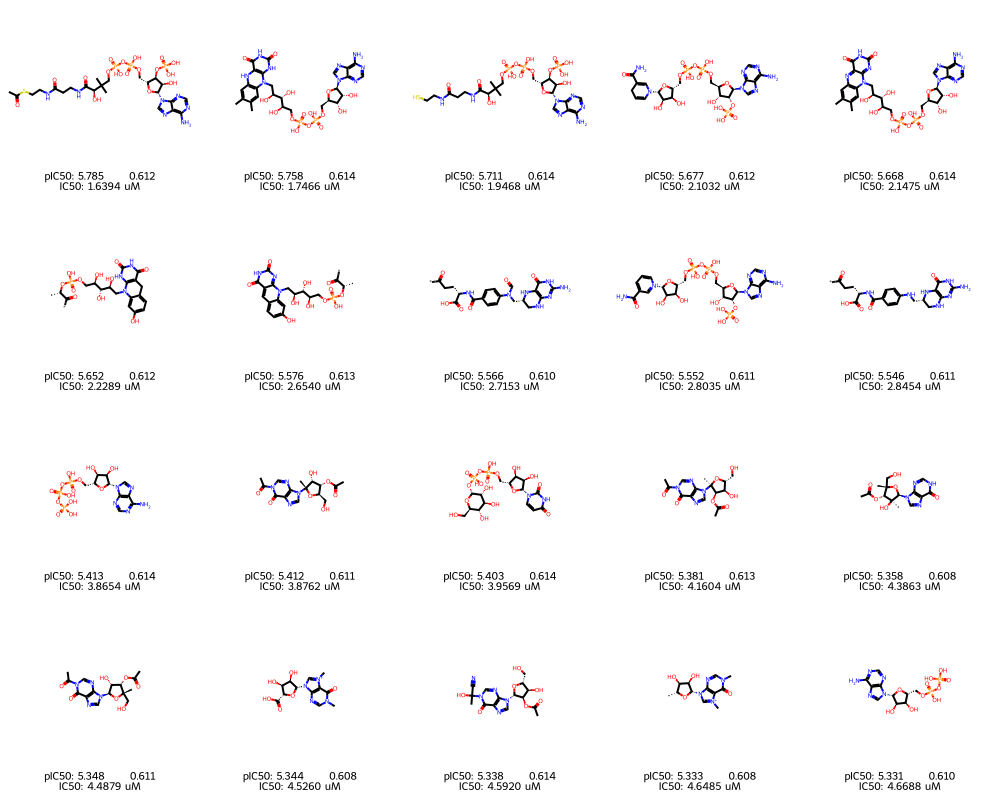

In [179]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_InosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_InosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'Ebola_InosineOnly_Antivirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'Ebola_InosineOnly_Antivirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

Saved GIF: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_InosineOnly_Antivirals_wARTprediction_top20_Compounds.gif


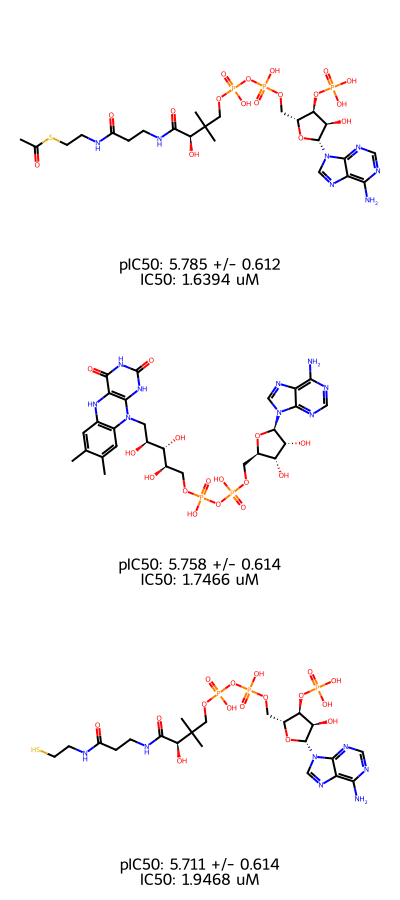

In [180]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_InosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_InosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'Ebola_InosineOnly_Antivirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

## Top20 potent compound generated from `Adenosine` only `DORAnet` run

In [181]:
Ebola_allDORAnetGenerated_Antivirals_wARTprediction = pd.read_csv(ARTresultsDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv')

Ebola_AdenosineOnly_Antivirals_wARTprediction = Ebola_allDORAnetGenerated_Antivirals_wARTprediction[
    Ebola_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'] == 'AdenosineOnly_gen3'].reset_index(drop=True)

print(f"Total molecules: {len(Ebola_allDORAnetGenerated_Antivirals_wARTprediction)}")
print(f"DORAnet molecules generated by Adenosine only: {len(Ebola_AdenosineOnly_Antivirals_wARTprediction)}")

max_val = Ebola_AdenosineOnly_Antivirals_wARTprediction['pPotency_prediction'].max()
min_val = Ebola_AdenosineOnly_Antivirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Ebola_AdenosineOnly_Antivirals_wARTprediction

Total molecules: 20372
DORAnet molecules generated by Adenosine only: 5229
pPotency_prediction range: 4.715 → 5.557


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,True,AdenosineOnly_gen3,5.2394,0.6077,4.0483,6.4305,0.0000,0.0000,0.0001
1,Nc1ncnc2c1ncn2[C@@]1(CO)OC[C@@H](O)[C@H]1O,False,AdenosineOnly_gen3,4.9896,0.6073,3.7992,6.1800,0.0000,0.0000,0.0002
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O)[C@H]1O,False,AdenosineOnly_gen3,5.2876,0.6073,4.0974,6.4778,0.0000,0.0000,0.0001
3,COC[C@H]1O[C@@H](n2cnc3c(N)ncnc32)[C@H](O)[C@@...,False,AdenosineOnly_gen3,5.1195,0.6076,3.9287,6.3103,0.0000,0.0000,0.0001
4,CO[C@H]1[C@@H](O)[C@H](n2cnc3c(N)ncnc32)O[C@@H...,False,AdenosineOnly_gen3,5.1030,0.6079,3.9115,6.2945,0.0000,0.0000,0.0001
...,...,...,...,...,...,...,...,...,...,...
5224,Nc1nc2nc3c1ncn3[C@@H]1O[C@H](C(N)O)[C@@H](O)[C...,False,AdenosineOnly_gen3,5.1016,0.6080,3.9098,6.2934,0.0000,0.0000,0.0001
5225,O=C1Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,False,AdenosineOnly_gen3,5.1561,0.6084,3.9635,6.3486,0.0000,0.0000,0.0001
5226,Nc1ncnc2c1ncn2[C@@H]1O[C@H](C(N)O)[C@@H](O)[C@...,False,AdenosineOnly_gen3,5.3165,0.6074,4.1261,6.5070,0.0000,0.0000,0.0001
5227,CNC(=O)[C@H]1O[C@@H](n2cnc3c(N)ncnc32)[C@H](O)...,False,AdenosineOnly_gen3,5.1851,0.6090,3.9915,6.3788,0.0000,0.0000,0.0001


### Filter out `top 20` compounds with higher `pPotency`

In [182]:
predicted_pPotency = Ebola_AdenosineOnly_Antivirals_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = Ebola_AdenosineOnly_Antivirals_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

Top 20 compounds cutoff pPotency: 5.44 ± 0.61 (IC50: 3.6264 µM)
Highest predicted pPotency: 5.56 ± 0.61 (IC50: 2.7745 µM)
pPotency range of top 20 compounds: pPotency --> 5.44 ± 0.61 - 5.56 ± 0.61; IC50 --> 3.6264 - 2.7745 µM


In [183]:
Ebola_AdenosineOnly_Antivirals_wARTprediction_top20 = Ebola_AdenosineOnly_Antivirals_wARTprediction.iloc[top_20_idx].copy()
Ebola_AdenosineOnly_Antivirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
Ebola_AdenosineOnly_Antivirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
Ebola_AdenosineOnly_Antivirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

Ebola_AdenosineOnly_Antivirals_wARTprediction_top20 = Ebola_AdenosineOnly_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Ebola_AdenosineOnly_Antivirals_wARTprediction_top20

output_csv = os.path.join(saveDir, "Ebola_AdenosineOnly_Antivirals_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "Ebola_AdenosineOnly_Antivirals_wARTprediction_top20_SMILESonly.csv")
Ebola_AdenosineOnly_Antivirals_wARTprediction_top20.to_csv(output_csv, index=False)
Ebola_AdenosineOnly_Antivirals_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

Ebola_AdenosineOnly_Antivirals_wARTprediction_top20

 Saved results: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_AdenosineOnly_Antivirals_wARTprediction_top20.csv
 Saved SMILES:  /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_AdenosineOnly_Antivirals_wARTprediction_top20_SMILESonly.csv


,Rank,SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
2117,1,CC(=O)N(C(C)=O)c1ncnc2c1ncn2[C@@H]1O[C@H](C(C)...,5.5570,0.6115,2.7745
2360,2,CC(=O)N(C(N)=O)c1ncnc2c1ncn2[C@@H]1O[C@H](C(C)...,5.5360,0.6114,2.9113
1439,3,CC(=O)N(C=O)c1ncnc2c1ncn2[C@@H]1O[C@H](C(C)O)[...,5.5320,0.6115,2.9370
2475,4,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C(=O)O)[C@@H...,5.5210,0.6131,3.0136
2593,5,CC(O)[C@H]1O[C@@H](n2cnc3c(NC(C)(C)O)ncnc32)[C...,5.5020,0.6076,3.1461
2051,6,CC(=O)N(C)c1ncnc2c1ncn2[C@@H]1O[C@H](C(C)O)[C@...,5.4970,0.6087,3.1866
5151,7,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,5.4850,0.6084,3.2719
1907,8,CC(O)Nc1ncnc2c1ncn2[C@@H]1OC(CO)=C[C@H]1O,5.4850,0.6110,3.2739
2042,9,CC(=O)N(C)c1ncnc2c1ncn2[C@@H]1O[C@H](C(=O)O)[C...,5.4840,0.6096,3.2844
2023,10,CC(O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C(C)O)[C@@H](...,5.4830,0.6076,3.2916


### Display molecules

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_AdenosineOnly_Antivirals_wARTprediction_top20_Compounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_AdenosineOnly_Antivirals_wARTprediction_top20_Compounds.svg


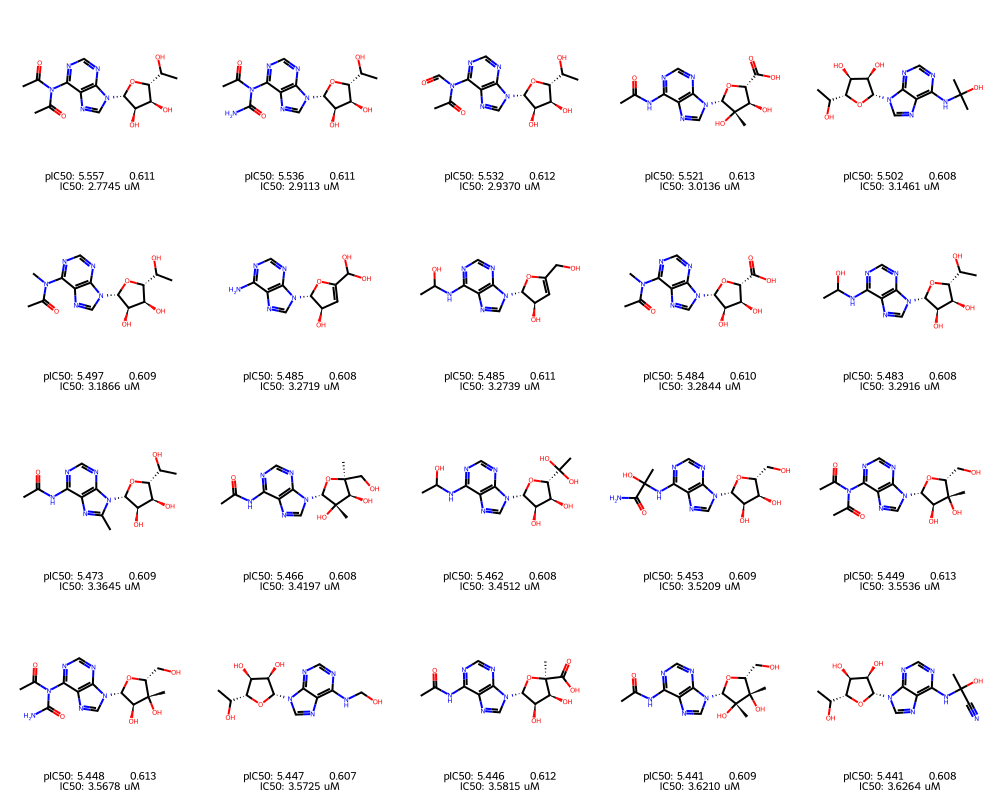

In [184]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_AdenosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_AdenosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'Ebola_AdenosineOnly_Antivirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'Ebola_AdenosineOnly_Antivirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

Saved GIF: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_AdenosineOnly_Antivirals_wARTprediction_top20_Compounds.gif


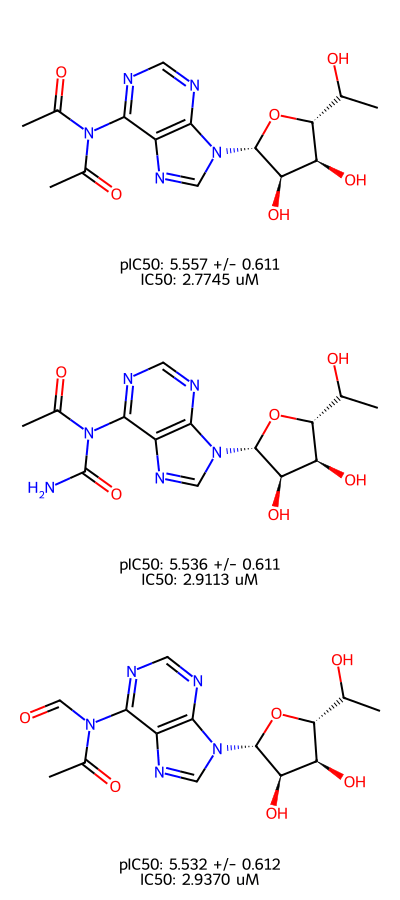

In [185]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_AdenosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_AdenosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'Ebola_AdenosineOnly_Antivirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

## Top20 potent compound generated from `Guanosine` only `DORAnet` run

In [186]:
Ebola_allDORAnetGenerated_Antivirals_wARTprediction = pd.read_csv(ARTresultsDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv')

Ebola_GuanosineOnly_Antivirals_wARTprediction = Ebola_allDORAnetGenerated_Antivirals_wARTprediction[
    Ebola_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'] == 'GuanosineOnly_gen3'].reset_index(drop=True)

print(f"Total molecules: {len(Ebola_allDORAnetGenerated_Antivirals_wARTprediction)}")
print(f"DORAnet molecules generated by Guanosine only: {len(Ebola_GuanosineOnly_Antivirals_wARTprediction)}")

max_val = Ebola_GuanosineOnly_Antivirals_wARTprediction['pPotency_prediction'].max()
min_val = Ebola_GuanosineOnly_Antivirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Ebola_GuanosineOnly_Antivirals_wARTprediction

Total molecules: 20372
DORAnet molecules generated by Guanosine only: 6116
pPotency_prediction range: 4.644 → 5.558


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,True,GuanosineOnly_gen3,5.0433,0.6083,3.8510,6.2356,0.0000,0.0000,0.0001
1,Nc1nc2c(ncn2[C@@]2(CO)OC[C@@H](O)[C@H]2O)c(=O)...,False,GuanosineOnly_gen3,4.8538,0.6086,3.6608,6.0467,0.0000,0.0000,0.0002
2,OC[C@H]1O[C@@H](n2cnc3c4nc(nc32)[nH]4)[C@H](O)...,False,GuanosineOnly_gen3,5.1012,0.6076,3.9102,6.2921,0.0000,0.0000,0.0001
3,Nc1nc2c(ncn2[C@@H]2O[C@H](COP(=O)(O)O)[C@@H](O...,False,GuanosineOnly_gen3,5.0809,0.6118,3.8818,6.2800,0.0000,0.0000,0.0001
4,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](OP(=O)(O)O...,False,GuanosineOnly_gen3,4.9408,0.6113,3.7427,6.1390,0.0000,0.0000,0.0002
...,...,...,...,...,...,...,...,...,...,...
6111,Nc1nc2c(ncn2[C@@H]2O[C@H](C(N)O)[C@@H](O)[C@H]...,False,GuanosineOnly_gen3,5.1158,0.6079,3.9243,6.3073,0.0000,0.0000,0.0001
6112,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C...,False,GuanosineOnly_gen3,5.0488,0.6141,3.8452,6.2524,0.0000,0.0000,0.0001
6113,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C...,False,GuanosineOnly_gen3,5.0485,0.6129,3.8473,6.2497,0.0000,0.0000,0.0001
6114,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[...,False,GuanosineOnly_gen3,5.1036,0.6118,3.9044,6.3028,0.0000,0.0000,0.0001


### Filter out `top 20` compounds with higher `pPotency`

In [187]:
predicted_pPotency = Ebola_GuanosineOnly_Antivirals_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = Ebola_GuanosineOnly_Antivirals_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

Top 20 compounds cutoff pPotency: 5.48 ± 0.61 (IC50: 3.3317 µM)
Highest predicted pPotency: 5.56 ± 0.61 (IC50: 2.7654 µM)
pPotency range of top 20 compounds: pPotency --> 5.48 ± 0.61 - 5.56 ± 0.61; IC50 --> 3.3317 - 2.7654 µM


In [188]:
Ebola_GuanosineOnly_Antivirals_wARTprediction_top20 = Ebola_GuanosineOnly_Antivirals_wARTprediction.iloc[top_20_idx].copy()
Ebola_GuanosineOnly_Antivirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
Ebola_GuanosineOnly_Antivirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
Ebola_GuanosineOnly_Antivirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

Ebola_GuanosineOnly_Antivirals_wARTprediction_top20 = Ebola_GuanosineOnly_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Ebola_GuanosineOnly_Antivirals_wARTprediction_top20

output_csv = os.path.join(saveDir, "Ebola_GuanosineOnly_Antivirals_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "Ebola_GuanosineOnly_Antivirals_wARTprediction_top20_SMILESonly.csv")
Ebola_GuanosineOnly_Antivirals_wARTprediction_top20.to_csv(output_csv, index=False)
Ebola_GuanosineOnly_Antivirals_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

Ebola_GuanosineOnly_Antivirals_wARTprediction_top20

 Saved results: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_GuanosineOnly_Antivirals_wARTprediction_top20.csv
 Saved SMILES:  /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_GuanosineOnly_Antivirals_wARTprediction_top20_SMILESonly.csv


,Rank,SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
1744,1,CC(=O)Nc1nc2c(c(=O)n1C)[n+](C)cn2[C@@H]1O[C@H]...,5.5580,0.6112,2.7654
2672,2,CC(=O)N(C(C)=O)c1nc2c(ncn2[C@@H]2O[C@H](C(=O)O...,5.5410,0.6171,2.8745
3131,3,CC(=O)Nc1nc2c(nc(C)n2[C@@H]2O[C@H](C(=O)O)[C@@...,5.5240,0.6138,2.9931
1752,4,CC(=O)Nc1nc2c(c(=O)[nH]1)[n+](C)cn2[C@@H]1O[C@...,5.5220,0.6118,3.0078
2603,5,CC(=O)N(C)c1nc2c(ncn2[C@@H]2O[C@H](C(=O)O)[C@@...,5.5200,0.6152,3.0213
2674,6,CC(=O)N(C(C)=O)c1nc2c(ncn2[C@@]2(C)O[C@H](CO)[...,5.5170,0.6148,3.0442
3129,7,CC(=O)Nc1nc2c(ncn2[C@@]2(C)O[C@H](C(=O)O)[C@@H...,5.5130,0.6131,3.0661
3003,8,CC(=O)N(C(N)=O)c1nc2c(ncn2[C@@]2(C)O[C@H](CO)[...,5.5100,0.6153,3.0903
1742,9,CC(=O)Nc1nc2c(c(=O)[nH]1)[n+](C)cn2[C@@H]1O[C@...,5.5100,0.6129,3.0934
3127,10,CC(=O)Nc1nc2c(ncn2[C@@H]2O[C@@](C)(C(=O)O)[C@@...,5.5040,0.6145,3.1359


### Display molecules

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_GuanosineOnly_Antivirals_wARTprediction_top20_Compounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_GuanosineOnly_Antivirals_wARTprediction_top20_Compounds.svg


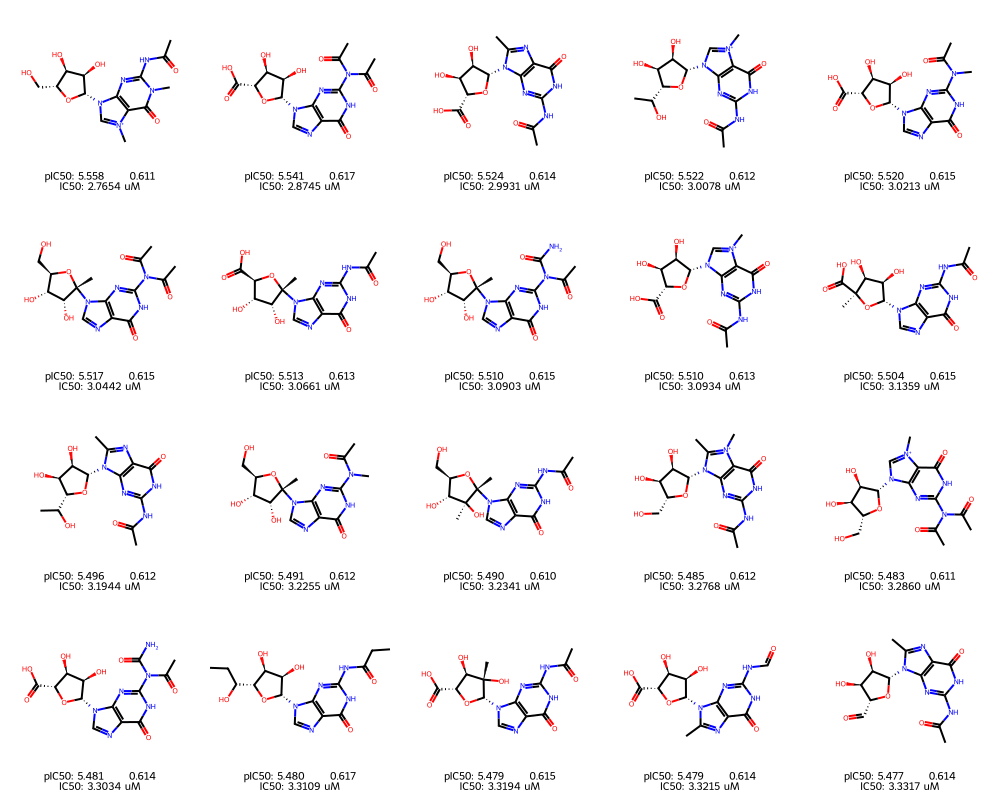

In [189]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_GuanosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_GuanosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'Ebola_GuanosineOnly_Antivirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'Ebola_GuanosineOnly_Antivirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

Saved GIF: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_GuanosineOnly_Antivirals_wARTprediction_top20_Compounds.gif


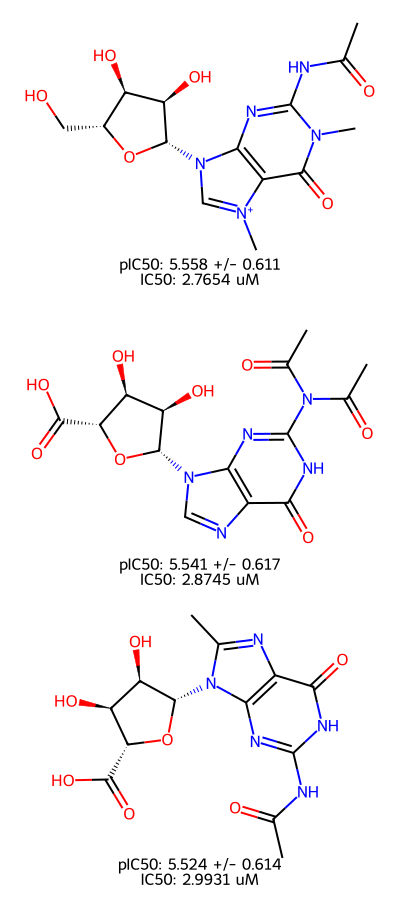

In [190]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_GuanosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_GuanosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'Ebola_GuanosineOnly_Antivirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

## Top20 potent compound generated from `Xanthosine` only `DORAnet` run

In [191]:
Ebola_allDORAnetGenerated_Antivirals_wARTprediction = pd.read_csv(ARTresultsDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv')

Ebola_XanthosineOnly_Antivirals_wARTprediction = Ebola_allDORAnetGenerated_Antivirals_wARTprediction[
    Ebola_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'] == 'XanthosineOnly_gen3'].reset_index(drop=True)

print(f"Total molecules: {len(Ebola_allDORAnetGenerated_Antivirals_wARTprediction)}")
print(f"DORAnet molecules generated by Xanthosine only: {len(Ebola_XanthosineOnly_Antivirals_wARTprediction)}")

max_val = Ebola_XanthosineOnly_Antivirals_wARTprediction['pPotency_prediction'].max()
min_val = Ebola_XanthosineOnly_Antivirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Ebola_XanthosineOnly_Antivirals_wARTprediction

Total molecules: 20372
DORAnet molecules generated by Xanthosine only: 4300
pPotency_prediction range: 4.619 → 5.406


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,True,XanthosineOnly_gen3,4.9863,0.6087,3.7933,6.1793,0.0000,0.0000,0.0002
1,O=c1[nH]c(=O)c2ncn([C@@]3(CO)OC[C@@H](O)[C@H]3...,False,XanthosineOnly_gen3,4.8198,0.6089,3.6264,6.0132,0.0000,0.0000,0.0002
2,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](COP(=O)(O)O)[...,False,XanthosineOnly_gen3,5.0469,0.6114,3.8486,6.2452,0.0000,0.0000,0.0001
3,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](OP(...,False,XanthosineOnly_gen3,4.9114,0.6115,3.7128,6.1100,0.0000,0.0000,0.0002
4,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,False,XanthosineOnly_gen3,4.8746,0.6125,3.6741,6.0751,0.0000,0.0000,0.0002
...,...,...,...,...,...,...,...,...,...,...
4295,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32...,False,XanthosineOnly_gen3,5.0958,0.6083,3.9036,6.2880,0.0000,0.0000,0.0001
4296,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.0040,0.6139,3.8008,6.2072,0.0000,0.0000,0.0002
4297,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.0464,0.6129,3.8452,6.2477,0.0000,0.0000,0.0001
4298,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c...,False,XanthosineOnly_gen3,5.0790,0.6112,3.8810,6.2770,0.0000,0.0000,0.0001


### Filter out `top 20` compounds with higher `pPotency`

In [192]:
predicted_pPotency = Ebola_XanthosineOnly_Antivirals_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = Ebola_XanthosineOnly_Antivirals_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

Top 20 compounds cutoff pPotency: 5.31 ± 0.62 (IC50: 4.8607 µM)
Highest predicted pPotency: 5.41 ± 0.61 (IC50: 3.9266 µM)
pPotency range of top 20 compounds: pPotency --> 5.31 ± 0.62 - 5.41 ± 0.61; IC50 --> 4.8607 - 3.9266 µM


In [193]:
Ebola_XanthosineOnly_Antivirals_wARTprediction_top20 = Ebola_XanthosineOnly_Antivirals_wARTprediction.iloc[top_20_idx].copy()
Ebola_XanthosineOnly_Antivirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
Ebola_XanthosineOnly_Antivirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
Ebola_XanthosineOnly_Antivirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

Ebola_XanthosineOnly_Antivirals_wARTprediction_top20 = Ebola_XanthosineOnly_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Ebola_XanthosineOnly_Antivirals_wARTprediction_top20

output_csv = os.path.join(saveDir, "Ebola_XanthosineOnly_Antivirals_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "Ebola_XanthosineOnly_Antivirals_wARTprediction_top20_SMILESonly.csv")
Ebola_XanthosineOnly_Antivirals_wARTprediction_top20.to_csv(output_csv, index=False)
Ebola_XanthosineOnly_Antivirals_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

Ebola_XanthosineOnly_Antivirals_wARTprediction_top20

 Saved results: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_XanthosineOnly_Antivirals_wARTprediction_top20.csv
 Saved SMILES:  /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_XanthosineOnly_Antivirals_wARTprediction_top20_SMILESonly.csv


,Rank,SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
1123,1,Cn1c(=O)c2c(n([C@@H]3O[C@H](CO)[C@@H](O)[C@H]3...,5.4060,0.6091,3.9266
3221,2,CC(=O)O[C@H]1[C@@H](O)[C@@](C)(n2cnc3c(=O)n(C(...,5.4020,0.6130,3.9670
1129,3,Cn1c(=O)[nH]c(=O)c2c1n([C@@H]1O[C@H](C(=O)O)[C...,5.3950,0.6121,4.0240
457,4,Cn1c(=O)[nH]c(=O)c2c1n([C@@H]1O[C@H](COP(=O)(O...,5.3790,0.6097,4.1788
1288,5,Cn1c(=O)[nH]c2c(c1=O)[n+](C)cn2[C@@H]1O[C@H](C...,5.3660,0.6103,4.3029
3147,6,CC(O)n1c(=O)[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C...,5.3580,0.6199,4.3808
3156,7,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(=...,5.3570,0.6093,4.3951
459,8,Cn1c(=O)[nH]c2c(c1=O)[n+](C)cn2[C@@H]1O[C@H](C...,5.3530,0.6091,4.4399
1128,9,C[C@H]1O[C@@H](n2c[n+](C)c3c(=O)[nH]c(=O)n(C)c...,5.3470,0.6101,4.4932
2163,10,CC(=O)n1c(=O)[nH]c(=O)c2ncn([C@@H]3O[C@H](COC(...,5.3420,0.6143,4.5465


### Display molecules

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_XanthosineOnly_Antivirals_wARTprediction_top20_Compounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_XanthosineOnly_Antivirals_wARTprediction_top20_Compounds.svg


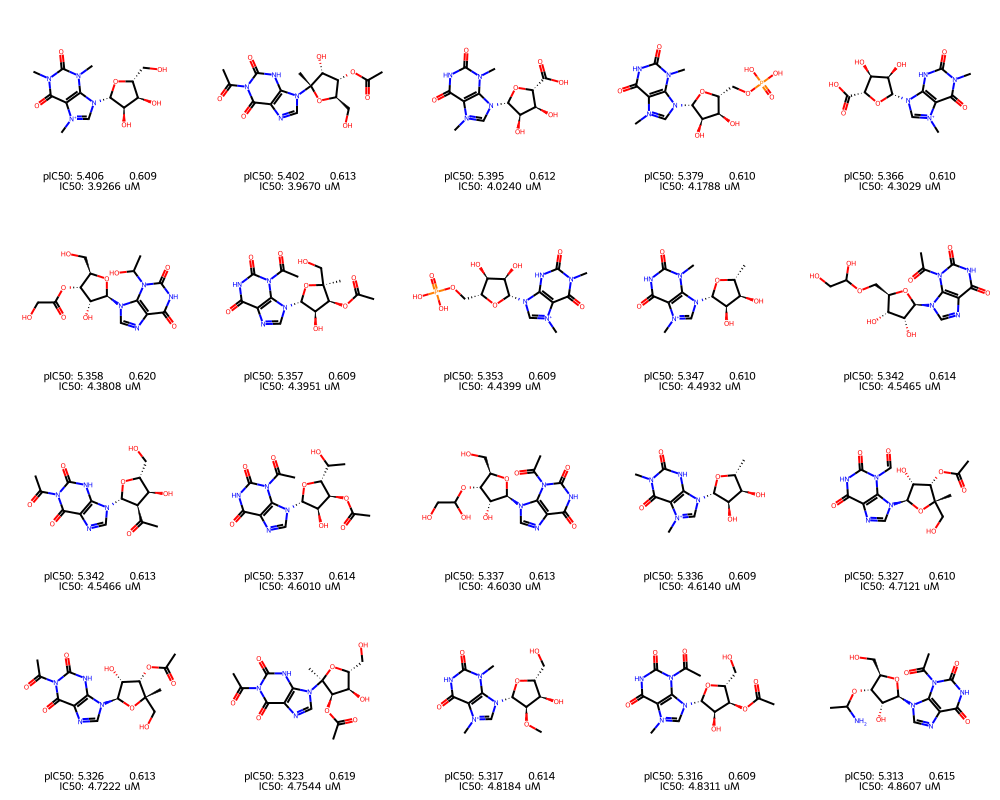

In [194]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_XanthosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_XanthosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'Ebola_XanthosineOnly_Antivirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'Ebola_XanthosineOnly_Antivirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

Saved GIF: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW/Ebola_XanthosineOnly_Antivirals_wARTprediction_top20_Compounds.gif


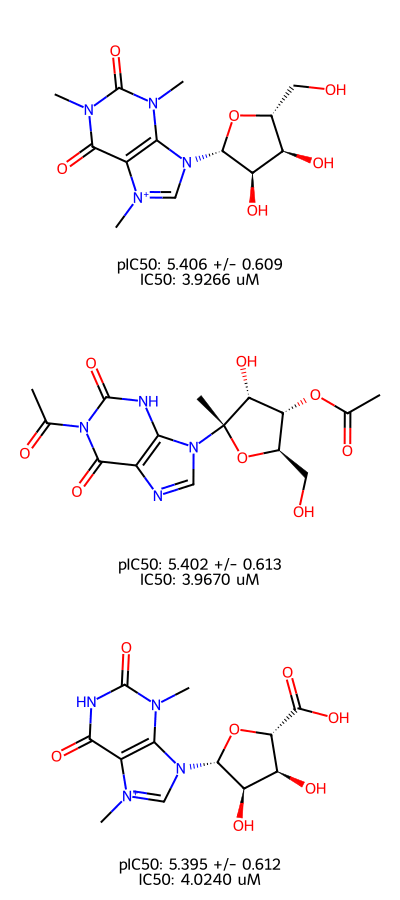

In [195]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_XanthosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_XanthosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'Ebola_XanthosineOnly_Antivirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

## Import all `Inosine Substructures` compounds generated by `DORAnet` --> Possible `Antivirals`

In [ ]:
InosineSubstructures_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "InosineSubstructures_DORAnetGeneratedMolecules.csv", dtype=str)
print(f"Loaded {len(InosineSubstructures_DORAnetGenerated)} molecules")
InosineSubstructures_DORAnetGenerated['source_DataBase'] = 'Inosine_Substructures'
InosineSubstructures_DORAnetGenerated

### Generate `MACAW` embeedings for `DORAnet` generated molecules --> to run external validation with `ART`

In [ ]:
# ---------------------------
# 1. LOAD MACAW TRANSFORMER AND GENERATE EMBEDDINGS
# ---------------------------
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(modelBuildingDataDir, "combinedEbolaVirusData_chEMBL_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(InosineSubstructures_DORAnetGenerated['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=InosineSubstructures_DORAnetGenerated.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
InosineSubstructures_DORAnetGenerated_wMACAW = pd.concat([InosineSubstructures_DORAnetGenerated, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {InosineSubstructures_DORAnetGenerated.shape}")
print(f"New dataframe shape: {InosineSubstructures_DORAnetGenerated_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
InosineSubstructures_DORAnetGenerated_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW.csv"), index=False)
InosineSubstructures_DORAnetGenerated_wMACAW.head()

### Import all `basidalin precursor` compounds generated by `DORAnet` --> Possible `Antibiotic`

In [ ]:
basidalinPrecursor_DORAnetGeneratedMolecules = pd.read_csv(DORANETmoleculesDataDir + "basidalinPrecursor_DORAnetGeneratedMolecules.csv", dtype=str)
print(f"Loaded {len(basidalinPrecursor_DORAnetGeneratedMolecules)} molecules")
basidalinPrecursor_DORAnetGeneratedMolecules['source_DataBase'] = 'basidalin_Precursor'
basidalinPrecursor_DORAnetGeneratedMolecules

### Generate `MACAW` embeedings for `DORAnet` generated molecules --> to run external validation with `ART`

In [ ]:
# ---------------------------
# 1. LOAD MACAW TRANSFORMER AND GENERATE EMBEDDINGS
# ---------------------------
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(modelBuildingDataDir, "combinedEbolaVirusData_chEMBL_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(basidalinPrecursor_DORAnetGeneratedMolecules['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=basidalinPrecursor_DORAnetGeneratedMolecules.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW = pd.concat([basidalinPrecursor_DORAnetGeneratedMolecules, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {basidalinPrecursor_DORAnetGeneratedMolecules.shape}")
print(f"New dataframe shape: {basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "combinedEbolaVirusData_basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW.csv"), index=False)
basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW.head()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("UMAP not installed. Install with: pip install umap-learn")


# ************************************************************
# 1. Prepare embedding matrix
# ************************************************************

embedding_columns = [col for col in basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW.columns if col.startswith('MACAW_')]
X_embeddings = basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW[embedding_columns].values

# Standardize before dimensionality reduction
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_embeddings)

print(f"Embedding matrix shape: {X_scaled.shape}")


# ************************************************************
# 2. t-SNE projection
# ************************************************************

tsne = TSNE(
    n_components=2,
    perplexity=min(30, X_scaled.shape[0] - 1),  # handle small datasets
    random_state=42,
    max_iter=1000,
    learning_rate='auto',
    init='pca'
)
X_tsne = tsne.fit_transform(X_scaled)

basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['tSNE_1'] = X_tsne[:, 0]
basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['tSNE_2'] = X_tsne[:, 1]

print(f"t-SNE complete. KL divergence: {tsne.kl_divergence_:.4f}")


# ************************************************************
# 3. UMAP projection (if available)
# ************************************************************

if HAS_UMAP:
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=min(15, X_scaled.shape[0] - 1),
        min_dist=0.1,
        metric='euclidean',
        random_state=42
    )
    X_umap = reducer.fit_transform(X_scaled)

    basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['UMAP_1'] = X_umap[:, 0]
    basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['UMAP_2'] = X_umap[:, 1]

    print("UMAP complete.")


# ************************************************************
# 4. Choose a property to color by (if available)
# ************************************************************

# Try to find a meaningful numeric column for coloring
color_col = None
for candidate in ['pIC50', 'IC50', 'MolWt', 'AtomicEconomy', 'NumPathways']:
    if candidate in basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW.columns:
        color_col = candidate
        break

if color_col is None:
    # Fall back: use molecular weight from RDKit
    from rdkit import Chem
    from rdkit.Chem import Descriptors
    mw_values = []
    for smi in basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['SMILES']:
        mol = Chem.MolFromSmiles(smi)
        mw_values.append(Descriptors.MolWt(mol) if mol else np.nan)
    basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['MolWt'] = mw_values
    color_col = 'MolWt'

print(f"Coloring by: {color_col}")


# ************************************************************
# 5. Plot t-SNE
# ************************************************************

fig, axes = plt.subplots(1, 2 if HAS_UMAP else 1, figsize=(20 if HAS_UMAP else 10, 8))

if not HAS_UMAP:
    axes = [axes]

color_values = basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW[color_col].values

# t-SNE plot
ax = axes[0]
scatter = ax.scatter(
    basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['tSNE_1'],
    basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['tSNE_2'],
    c=color_values,
    cmap='viridis',
    s=30,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.3
)
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label(color_col, fontsize=12)
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('MACAW Embedding Space (t-SNE)', fontsize=14)
ax.grid(True, alpha=0.3)

# UMAP plot
if HAS_UMAP:
    ax = axes[1]
    scatter = ax.scatter(
        basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['UMAP_1'],
        basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['UMAP_2'],
        c=color_values,
        cmap='viridis',
        s=30,
        alpha=0.7,
        edgecolors='white',
        linewidths=0.3
    )
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
    cbar.set_label(color_col, fontsize=12)
    ax.set_xlabel('UMAP 1', fontsize=12)
    ax.set_ylabel('UMAP 2', fontsize=12)
    ax.set_title('MACAW Embedding Space (UMAP)', fontsize=14)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig(os.path.join(modelBuildingDataDir, 'MACAW_embedding_space_2D.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTotal molecules plotted: {len(X_scaled)}")


# ************************************************************
# 6. Optional: KMeans clustering overlay
# ************************************************************

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Find optimal number of clusters using silhouette score
best_k = 2
best_score = -1
max_k = min(15, X_scaled.shape[0] // 2)

for k in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    if score > best_score:
        best_score = score
        best_k = k

print(f"Optimal clusters: {best_k} (silhouette score: {best_score:.3f})")

# Fit with optimal k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW['Cluster'] = cluster_labels

# Plot with cluster coloring
fig, axes = plt.subplots(1, 2 if HAS_UMAP else 1, figsize=(20 if HAS_UMAP else 10, 8))

if not HAS_UMAP:
    axes = [axes]

cmap_discrete = plt.cm.get_cmap('tab10', best_k)

# t-SNE with clusters
ax = axes[0]
for cl in range(best_k):
    mask = cluster_labels == cl
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=[cmap_discrete(cl)],
        label=f'Cluster {cl} (n={mask.sum()})',
        s=30, alpha=0.7,
        edgecolors='white', linewidths=0.3
    )
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title(f'MACAW Embedding Clusters (t-SNE, k={best_k})', fontsize=14)
ax.legend(fontsize=9, frameon=False, loc='best')
ax.grid(True, alpha=0.3)

# UMAP with clusters
if HAS_UMAP:
    ax = axes[1]
    for cl in range(best_k):
        mask = cluster_labels == cl
        ax.scatter(
            X_umap[mask, 0], X_umap[mask, 1],
            c=[cmap_discrete(cl)],
            label=f'Cluster {cl} (n={mask.sum()})',
            s=30, alpha=0.7,
            edgecolors='white', linewidths=0.3
        )
    ax.set_xlabel('UMAP 1', fontsize=12)
    ax.set_ylabel('UMAP 2', fontsize=12)
    ax.set_title(f'MACAW Embedding Clusters (UMAP, k={best_k})', fontsize=14)
    ax.legend(fontsize=9, frameon=False, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig(os.path.join(modelBuildingDataDir, 'MACAW_embedding_clusters_2D.png'), dpi=300, bbox_inches='tight')
plt.show()

# Cluster summary
print("\nCluster summary:")
clusterSummary = basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW.groupby('Cluster').agg(
    Count=('SMILES', 'count'),
    **({f'Mean_{color_col}': (color_col, 'mean')} if color_col in basidalinPrecursor_DORAnetGeneratedMolecules_wMACAW.columns else {})
).reset_index()
print(clusterSummary.to_string(index=False))

### Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [ ]:
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction = pd.read_csv(ARTresultsDir + 'combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction.csv')
max_val = InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction['pPotency_prediction'].max()
min_val = InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction

### Extract `pPotency` predictions

In [ ]:
predicted_pPotency = InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction['pPotency_prediction'].values

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]  # Last (20th) value
highest_pPotency = predicted_pPotency[top_20_idx[0]]   # First (1st) value

# Convert to IC50 in µM
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} - {highest_pPotency:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Create dataframe with top 20
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20 = InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)

# Add IC50 column in micromolar (µM)
# IC50 (µM) = 10^(-pPotency) * 1e6
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6

# Add rank column at the beginning
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = predicted_pPotency[top_20_idx[0]]   # Highest (best)
pPotency_min = predicted_pPotency[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min_uM = 10**(-pPotency_max) * 1e6            # Lowest IC50 (most potent)
IC50_max_uM = 10**(-pPotency_min) * 1e6            # Highest IC50 (least potent in top 20)

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max_uM:.4f} µM")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min_uM:.4f} µM")

print("\nRange for Top 20 Compounds:")
print(f"pPotency Range:   {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"IC50 Range (µM):  {IC50_max_uM:.4f} - {IC50_min_uM:.4f}")

# Set pandas display options
pd.options.display.float_format = lambda x: f'{x:.4f}'

# Display the dataframe
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20 = InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20

In [ ]:
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.to_csv(os.path.join(saveDir + "InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.csv"), index=False)
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20[['SMILES']].to_csv(os.path.join(saveDir + "InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20_SMILESonly.csv"), index=False)

In [ ]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)

### Save molecules as .gif

In [ ]:
# Get molecules and legends
molecules = [Chem.MolFromSmiles(smi) for smi in InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

# Split molecules into chunks of 4 for each frame
mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]
    
    # Generate grid image: 1 column (vertical layout), 4 rows
    frame_img = Draw.MolsToGridImage(
        chunk_mols,
        subImgSize=(400, 300),
        molsPerRow=1,  # 1 per row = vertical arrangement
        useSVG=False,
        legends=chunk_legends,
        returnPNG=False
    )
    
    # Convert to RGB if necessary (GIF requires consistent mode)
    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')
    
    frames.append(frame_img)

# Save as GIF
output_gif = saveDir + 'InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=3000,  # 3 seconds per frame
    loop=2,         # 0 = infinite loop
    optimize=True
)
print(f"Saved GIF: {output_gif}")

# Display in notebook
from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

### Checking drug likeliness of `Remdesivir` and `Molnupiravir`

In [ ]:
Remdesivir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Remdesivir_structure.mol")
Molnupiravir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Molnupiravir_structure.mol")

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Molnupiravir_SMILES = 'CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O'

# Dictionary of drugs and their SMILES
drugs = {
    'Remdesivir': Remdesivir_SMILES,
    'Molnupiravir': Molnupiravir_SMILES
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
smi_lib_DTRA_targets = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib_DTRA_targets)}")
DTRA_target_SMILES

Generate predictions

In [ ]:
smi_lib = smi_lib_DTRA_targets.copy()
smi_lib_DTRA_targets_wMACAW = mcw.transform(smi_lib_DTRA_targets)

# Create column names
num_features = smi_lib_DTRA_targets_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
smi_lib_DTRA_targets = pd.DataFrame(smi_lib_DTRA_targets_wMACAW, columns=column_names, index=smi_lib.index)
# Then add SMILES as first column
smi_lib_DTRA_targets.insert(0, 'SMILES', smi_lib)
# Save to CSV
smi_lib_DTRA_targets.to_csv(os.path.join(saveDir + "combinedEbolaVirus_DTRA_smiles_wMACAW.csv"), index=False)
smi_lib_DTRA_targets

### Import ART predictions

In [ ]:
DTRA_target_SMILES_predicted = pd.read_csv(saveDir + 'combinedEbolaVirus_wART_DTRA_target_antivirals_predicted_all.csv')
max_val = DTRA_target_SMILES_predicted['pPotency_prediction'].max()
min_val = DTRA_target_SMILES_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

def canonical(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

DTRA_target_SMILES['can_smiles'] = DTRA_target_SMILES['SMILES'].apply(canonical)
DTRA_target_SMILES_predicted['can_smiles'] = DTRA_target_SMILES_predicted['SMILES'].apply(canonical)

DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.merge(
    DTRA_target_SMILES[['can_smiles', 'Drug_Name']],
    on='can_smiles',
    how='left')

cols = ['Drug_Name'] + [c for c in DTRA_target_SMILES_predicted.columns if c != 'Drug_Name']
DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted[cols]
DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.drop(columns=['can_smiles'])
DTRA_target_SMILES_predicted

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in DTRA_target_SMILES_predicted.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in DTRA_target_SMILES_predicted[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50(M)_prediction']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50(M)_prediction']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'combinedEbolaVirus_DTRA_target_antivirals_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'combinedEbolaVirus_DTRA_target_antivirals_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### Now take top to molecules from each data set and check which are non-toxic

-- Please check this notebook: Step6_Toxicity_AllVirus

# Run the same code by removing duplicate SMILES

In [ ]:
combinedEbolaVirusData_chEMBL

### Remove duplicate compounds using Compute median potency per (Smiles, Virus) pair

In [ ]:
# Print shape before removing duplicates
print("Before removing duplicates:", combinedEbolaVirusData_chEMBL.shape)

# Aggregate duplicates *within the same Virus*
aggDF = (
    combinedEbolaVirusData_chEMBL.groupby(['Smiles', 'StrainClassifier'], as_index=False)
      .agg({'pPotency': 'median'})   # or 'mean' if you prefer
)

# Merge back non-target columns (like MACAW features)
combinedEbolaVirusData_chEMBL_noDuplicates = (aggDF
      .merge(
          aggDF.drop(columns=['pPotency']),
          on=['Smiles', 'StrainClassifier'],
          how='left'
      )
      .drop_duplicates(subset=['Smiles', 'StrainClassifier'])
      .reset_index(drop=True)
)

# Print shape after removing duplicates
print("After removing duplicates:", combinedEbolaVirusData_chEMBL_noDuplicates.shape)

In [ ]:
duplicates = combinedEbolaVirusData_chEMBL_noDuplicates.duplicated(subset=['Smiles', 'StrainClassifier'])
print("Remaining duplicates:", duplicates.sum())

In [ ]:
# Get counts and percentages
counts = combinedEbolaVirusData_chEMBL_noDuplicates['StrainClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
combinedEbolaVirusData_chEMBL_noDuplicates.to_csv(os.path.join(modelBuildingDataDir, "combinedEbolaVirusData_chEMBL_noDuplicates_MLready.csv"), index=False)

### pPotency value distribution across each Virus

In [ ]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=combinedEbolaVirusData_chEMBL_noDuplicates,
    x='StrainClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=combinedEbolaVirusData_chEMBL_noDuplicates,
    x='StrainClassifier',
    y='pPotency',
    jitter=True,          # spreads the dots to avoid overlap
    palette='Set2',
    alpha=1
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency values per Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Create MACAW embeedings to run ART

In [ ]:
# ---------------------------
# 1. FIT MACAW AND GENERATE EMBEDDINGS
# ---------------------------
# Initialize MACAW
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=42
)

# Fit MACAW on SMILES and pPotency
mcw.fit(combinedEbolaVirusData_chEMBL_noDuplicates['Smiles'], combinedEbolaVirusData_chEMBL_noDuplicates['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(modelBuildingDataDir, "combinedEbolaVirusData_chEMBL_noDuplicates_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(combinedEbolaVirusData_chEMBL_noDuplicates['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=combinedEbolaVirusData_chEMBL_noDuplicates.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
combinedEbolaVirusData_chEMBL_noDuplicates_wMACAW = pd.concat([combinedEbolaVirusData_chEMBL_noDuplicates, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {combinedEbolaVirusData_chEMBL_noDuplicates.shape}")
print(f"New dataframe shape: {combinedEbolaVirusData_chEMBL_noDuplicates_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
combinedEbolaVirusData_chEMBL_noDuplicates_wMACAW

In [ ]:
combinedEbolaVirusData_chEMBL_noDuplicates_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "combinedEbolaVirusData_chEMBL_noDuplicates_wMACAW.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [ ]:
# df = combinedEbolaVirusData_chEMBL_noDuplicates
Y = combinedEbolaVirusData_chEMBL_noDuplicates.pPotency
smiles = combinedEbolaVirusData_chEMBL_noDuplicates.Smiles

In [ ]:
print(len(smiles))

In [ ]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [ ]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [ ]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [ ]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=42
)


After cleaning NaN values, reset the indices

In [ ]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

### ML predictions with Train + Test results

In [ ]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")

In [ ]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + 'combinedEbolaVirus_noDuplicates_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [ ]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=42
)
mcw.fit(smiles, Y)

In [ ]:
X_all = mcw.transform(smiles)
X_all.shape

In [ ]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)

# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=saveDir + 'combinedEbolaVirus_noDuplicates_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

### Compare performance of different ML model

- SVR
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Neural Network

Import all necessary libraries

## 2.1 Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
EnamineAntiviralsData = pd.read_csv(dataDir + "Enamine/Enamine_Antiviral_Library_plated_3200cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                    skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntiviralsData.shape}")

smiles_train = combinedEbolaVirusData_chEMBL_noDuplicates.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntiviralsData['Canonical_SMILES'] = EnamineAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntiviralsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntiviralsData_filtered = EnamineAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntiviralsData = EnamineAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntiviralsData.shape}")
print(f"Removed {EnamineAntiviralsData.shape[0] - EnamineAntiviralsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib = EnamineAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
EnamineAntiviralsData.head()

Generate predictions for the H1 receptor:

In [ ]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [ ]:
EnamineAntiviralsData_predicted = EnamineAntiviralsData.copy()
EnamineAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
EnamineAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-EnamineAntiviralsData_predicted['pPotency_prediction'])

EnamineAntiviralsData_predicted = EnamineAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
EnamineAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_EnamineDataset_predicted_all.csv"), index=False)
EnamineAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_EnamineDataset_predicted_all_SMILES.csv"), index=False)
EnamineAntiviralsData_predicted

Let us represent the predictions of both models:

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'combinedEbolaVirus_noDuplicates_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'combinedEbolaVirus_noDuplicates_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

In [ ]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

### Top 20 compounds with higher PpPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntiviralsData_top20 = EnamineAntiviralsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntiviralsData_top20 = EnamineAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntiviralsData_top20

In [ ]:
EnamineAntiviralsData_top20.to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_EnamineAntiviralsData_top20.csv"), index=False)
EnamineAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_EnamineAntiviralsData_top20_SMILES.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = saveDir + ''
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'combinedEbolaVirus_noDuplicates_enamine_predictedCompounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'combinedEbolaVirus_noDuplicates_enamine_predictedCompounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

## 2.2 Discovery of new hits specific to all viruses (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Merged_Antiviral_Screening_Superset.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntiviralsData_superset = pd.DataFrame(records)
print(f"Original LifeChemicals data shape: {LCAntiviralsData_superset.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntiviralsData_superset['Canonical_SMILES'] = LCAntiviralsData_superset['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntiviralsData_superset['Canonical_SMILES'].isin(canonical_train)
LCAntiviralsData_superset_filtered = LCAntiviralsData_superset[mask].copy()

# Remove the helper column if you don't need it
LCAntiviralsData_superset = LCAntiviralsData_superset_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntiviralsData_superset.shape}")
print(f"Removed {LCAntiviralsData_superset_filtered.shape[0] - LCAntiviralsData_superset.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib = LCAntiviralsData_superset.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
LCAntiviralsData_superset.head()

Generate predictions for the H1 receptor:

In [ ]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [ ]:
LCAntiviralsData_predicted = LCAntiviralsData_superset.copy()
LCAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
LCAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-LCAntiviralsData_predicted['pPotency_prediction'])

LCAntiviralsData_predicted = LCAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
LCAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_LCDatasets_predicted_all.csv"), index=False)
LCAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_LCDatasets_predicted_all_SMILES.csv"), index=False)
LCAntiviralsData_predicted

Let us represent the predictions of both models:

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'combinedEbolaVirus_noDuplicates_validation_LCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'combinedEbolaVirus_noDuplicates_validation_LCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

In [ ]:
LCAntiviralsData_superset_final = LCAntiviralsData_superset.iloc[idx].copy()
LCAntiviralsData_superset_final['pPotency_prediction'] = Y1_lib_pred[idx]
LCAntiviralsData_superset_final = LCAntiviralsData_superset_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
LCAntiviralsData_superset_final

### Top 20 compounds with higher PpPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntiviralsData_top20 = LCAntiviralsData_superset.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntiviralsData_top20 = LCAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntiviralsData_top20

In [ ]:
LCAntiviralsData_top20.to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_LCAntiviralsData_top20.csv"), index=False)
LCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_LCAntiviralsData_top20_SMILES.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = saveDir + ''
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'combinedEbolaVirus_noDuplicates_predictedCompounds_LCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'combinedEbolaVirus_noDuplicates_predictedCompounds_LCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

# 2.3 Discovery of new hits specific to all viruses (data source chemDiv data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antiviral-Library-64958.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiviralsData = pd.DataFrame(records)
print(f"Original ChemDiv data shape: {ChemDivAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiviralsData['Canonical_SMILES'] = ChemDivAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiviralsData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiviralsData_filtered = ChemDivAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiviralsData = ChemDivAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiviralsData.shape}")
print(f"Removed {ChemDivAntiviralsData_filtered.shape[0] - ChemDivAntiviralsData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib = ChemDivAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
ChemDivAntiviralsData

In [ ]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [ ]:
ChemDivAntiviralsData_predicted = ChemDivAntiviralsData.copy()
ChemDivAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
ChemDivAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-ChemDivAntiviralsData_predicted['pPotency_prediction'])

ChemDivAntiviralsData_predicted = ChemDivAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
ChemDivAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_ChemDivDatasets_predicted_all.csv"), index=False)
ChemDivAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_ChemDivDatasets_predicted_all_SMILES.csv"), index=False)
ChemDivAntiviralsData_predicted

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'combinedEbolaVirus_ChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'combinedEbolaVirus_ChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

In [ ]:
ChemDivAntiviralsData_final = ChemDivAntiviralsData.iloc[idx].copy()
ChemDivAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]
ChemDivAntiviralsData_final = ChemDivAntiviralsData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
ChemDivAntiviralsData_final

### Top 20 compounds with higher pPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
ChemDivAntiviralsData_top20

In [ ]:
ChemDivAntiviralsData_top20.to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_ChemDivAntiviralsData_top20.csv"), index=False)
ChemDivAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_ChemDivAntiviralsData_top20_SMILES.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'Ebolavirus/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in ChemDivAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'EbolaVirus_predictedCompounds_noDuplicates_ChemDivDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'EbolaVirus_predictedCompounds_noDuplicates_ChemDivDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.4 Discovery of new hits specific to all viruses (data source SMACC Antivirals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
SMACCAntiviralsData = pd.read_csv(modelBuildingDataDir + "SMACCAntiviralsData_clean.csv")

# Check for duplicates
dup_check = SMACCAntiviralsData.groupby('SMILES')['pIC50'].agg(['count', 'median', 'std'])
duplicates = dup_check[dup_check['count'] > 1]
print(f"Original SMACC data shape: {SMACCAntiviralsData.shape}, with Duplicate SMILES: {len(duplicates)}")

# Take median pIC50 for duplicates
SMACCAntiviralsData = SMACCAntiviralsData.groupby('SMILES').agg({
    'Molecule ChEMBL ID': 'first',
    'pIC50': 'median',  # Use median instead of mean
    'Virus': 'first'
}).reset_index()

print(f"After removing internal duplicates: {SMACCAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")
# Add canonical SMILES column to SMACC data (reusing canonical_train from previous code)
SMACCAntiviralsData['Canonical_SMILES'] = SMACCAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~SMACCAntiviralsData['Canonical_SMILES'].isin(canonical_train)
SMACCAntiviralsData_filtered = SMACCAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
SMACCAntiviralsData = SMACCAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered SMACC data shape for validation: {SMACCAntiviralsData.shape}")
print(f"Removed {SMACCAntiviralsData_filtered.shape[0] - SMACCAntiviralsData.shape[0]} duplicate compounds from SMACC data set")
SMACCAntiviralsData = SMACCAntiviralsData.rename(columns={'pIC50': 'pIC50_experimental'})

smi_lib = SMACCAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
SMACCAntiviralsData.head()

Generate predictions

In [ ]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [ ]:
SMACCAntiviralsData_predicted = SMACCAntiviralsData.copy()
SMACCAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
SMACCAntiviralsData_predicted['IC50(M)_experimental'] = 10 ** (-SMACCAntiviralsData_predicted['pIC50_experimental'])
SMACCAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-SMACCAntiviralsData_predicted['pPotency_prediction'])

SMACCAntiviralsData_predicted = SMACCAntiviralsData_predicted.filter(
    items=["SMILES", "Virus", "pIC50_experimental", "pPotency_prediction",  "IC50(M)_experimental", "pPotency(M)_prediction"]
)
SMACCAntiviralsData_predicted

In [ ]:
SMACCAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_SMACCAntiviralsData_predicted_all.csv"), index=False)
SMACCAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_SMACCAntiviralsData_predicted_all_SMILES.csv"), index=False)

### Plot the error between `experimental_pPotency` and `predicted_pPotency`

In [ ]:
# Calculate residuals (difference)
SMACCAntiviralsData_predicted['residuals'] = (
    SMACCAntiviralsData_predicted['pPotency_prediction'] - 
    SMACCAntiviralsData_predicted['pIC50_experimental']
)

# Print statistics
print(f"Mean Residual: {SMACCAntiviralsData_predicted['residuals'].mean():.3f}")
print(f"Std Dev of Residuals: {SMACCAntiviralsData_predicted['residuals'].std():.3f}")
print(f"Min Residual: {SMACCAntiviralsData_predicted['residuals'].min():.3f}")
print(f"Max Residual: {SMACCAntiviralsData_predicted['residuals'].max():.3f}")

# Create residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Experimental values
axes[0].scatter(SMACCAntiviralsData_predicted['pIC50_experimental'], 
                SMACCAntiviralsData_predicted['residuals'], 
                alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_xlabel('Experimental pIC50', fontsize=12)
axes[0].set_ylabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[0].set_title('Residual Plot', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution of residuals
axes[1].hist(SMACCAntiviralsData_predicted['residuals'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(x=SMACCAntiviralsData_predicted['residuals'].mean(), 
                color='blue', linestyle='--', linewidth=2, 
                label=f'Mean: {SMACCAntiviralsData_predicted["residuals"].mean():.3f}')
axes[1].set_xlabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Residual Plot Analysis

In [ ]:
print(f"Mean residual: {SMACCAntiviralsData_predicted['residuals'].mean():.3f} (Close to 0 indicates no systematic bias)")
print(f"Std deviation: {SMACCAntiviralsData_predicted['residuals'].std():.3f} (typical prediction error)")
print(f"95% of predictions are within ±{1.96 * SMACCAntiviralsData_predicted['residuals'].std():.3f} pIC50 units")

Let us have a look at the compounds:

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'combinedEbolaVirus_noDuplicates_validation_noDuplicates_SMACCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'combinedEbolaVirus_noDuplicates_validation_noDuplicates_SMACCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

### Top 20 compounds with higher pPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
SMACCAntiviralsData_top20 = SMACCAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
SMACCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
SMACCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
SMACCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'


SMACCAntiviralsData_top20

In [ ]:
SMACCAntiviralsData_top20.to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_SMACCAntiviralsData_top20.csv"), index=False)
SMACCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_SMACCAntiviralsData_top20_SMILES.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = saveDir + ''
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in SMACCAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in SMACCAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'combinedEbolaVirus_predictedCompounds_noDuplicates_SMACCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'combinedEbolaVirus_predictedCompounds_noDuplicates_SMACCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### Checking drug likeliness of `Remdesivir` and `Molnupiravir`

In [ ]:
Remdesivir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Remdesivir_structure.mol")
Molnupiravir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Molnupiravir_structure.mol")

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Molnupiravir_SMILES = 'CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O'

# Dictionary of drugs and their SMILES
drugs = {
    'Remdesivir': Remdesivir_SMILES,
    'Molnupiravir': Molnupiravir_SMILES
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
DTRA_target_SMILES

In [ ]:
# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to DTRA target data
DTRA_target_SMILES['Canonical_SMILES'] = DTRA_target_SMILES['SMILES'].apply(canonicalize_smiles)

# ADDED: Save original count BEFORE filtering
original_count = DTRA_target_SMILES.shape[0]

# Filter out duplicates - keep only those NOT in training set
mask = ~DTRA_target_SMILES['Canonical_SMILES'].isin(canonical_train)
DTRA_target_SMILES_filtered = DTRA_target_SMILES[mask].copy()

# Remove the helper column if you don't need it
DTRA_target_SMILES = DTRA_target_SMILES_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered DTRA target data shape for validation: {DTRA_target_SMILES.shape}")
print(f"Removed {original_count - DTRA_target_SMILES.shape[0]} duplicate compounds from DTRA target data set")  # FIXED

# Now use the filtered data
smi_lib = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib)}")

# Display the filtered data
DTRA_target_SMILES

Generate predictions

In [ ]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [ ]:
DTRA_target_SMILES_predicted = DTRA_target_SMILES.copy()
DTRA_target_SMILES_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
DTRA_target_SMILES_predicted['pPotency(M)_prediction'] = 10 ** (-DTRA_target_SMILES_predicted['pPotency_prediction'])

DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
DTRA_target_SMILES_predicted.to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_DTRAtargets_predicted_all.csv"), index=False)
DTRA_target_SMILES_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "combinedEbolaVirus/combinedEbolaVirus_noDuplicates_DTRAtargets_predicted_all_SMILES.csv"), index=False)
DTRA_target_SMILES_predicted

### Checking efficiency of `Remdesivir` as a antiviral, it present in training data set

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'

# Dictionary of drugs and their SMILES
drugs = {
    'Remdesivir': Remdesivir_SMILES,
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
DTRA_target_SMILES

Find experimental pPotency value for `Remdesivir`

In [ ]:
# Function to canonicalize SMILES
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol, canonical=True) if mol else None
    except:
        return None

# Create mappings from allVirusData (without modifying it)
canonical_smiles = combinedEbolaVirusData_chEMBL_noDuplicates['Smiles'].apply(canonicalize_smiles)
smiles_to_pPotency = dict(zip(canonical_smiles, combinedEbolaVirusData_chEMBL_noDuplicates['pPotency']))
smiles_to_virus = dict(zip(canonical_smiles, combinedEbolaVirusData_chEMBL_noDuplicates['StrainClassifier']))

# Add columns to DTRA_target_SMILES
DTRA_target_SMILES['pIC50_experimental'] = DTRA_target_SMILES['SMILES'].apply(
    lambda x: smiles_to_pPotency.get(canonicalize_smiles(x), None)
)
DTRA_target_SMILES['StrainClassifier'] = DTRA_target_SMILES['SMILES'].apply(
    lambda x: smiles_to_virus.get(canonicalize_smiles(x), None)
)

# Display
print(f"Compounds with experimental data: {DTRA_target_SMILES['pIC50_experimental'].notna().sum()}")
DTRA_target_SMILES

In [ ]:
# Now use the filtered data
smi_lib = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib)}")

Generate predictions

In [ ]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [ ]:
DTRA_target_SMILES_predicted = DTRA_target_SMILES.copy()
DTRA_target_SMILES_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
DTRA_target_SMILES_predicted['IC50(M)_experimental'] = 10 ** (-DTRA_target_SMILES_predicted['pIC50_experimental'])
DTRA_target_SMILES_predicted['pPotency(M)_prediction'] = 10 ** (-DTRA_target_SMILES_predicted['pPotency_prediction'])

DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.filter(
    items=["SMILES", "VirusClassifier", "pIC50_experimental", "pPotency_prediction",  "IC50(M)_experimental", "pPotency(M)_prediction"]
)
DTRA_target_SMILES_predicted